In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import pandas as pd
from numpy import corrcoef
from statsmodels.stats.multitest import multipletests

from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.colorbar as cbar

from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

from kneed import KneeLocator  

import scipy.io as sio
from scipy import stats
from scipy.stats import spearmanr, pearsonr, rankdata, norm, hypergeom, ttest_ind, kurtosis, skew, zscore

from scipy.spatial.distance import squareform, pdist
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import nibabel as nib
from nilearn import plotting, surface, datasets, image
from nilearn.surface import vol_to_surf
from nibabel.orientations import axcodes2ornt, ornt_transform, aff2axcodes

import statsmodels.api as sm
from statsmodels.formula.api import ols
import random
import pingouin as pg
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Figure 1

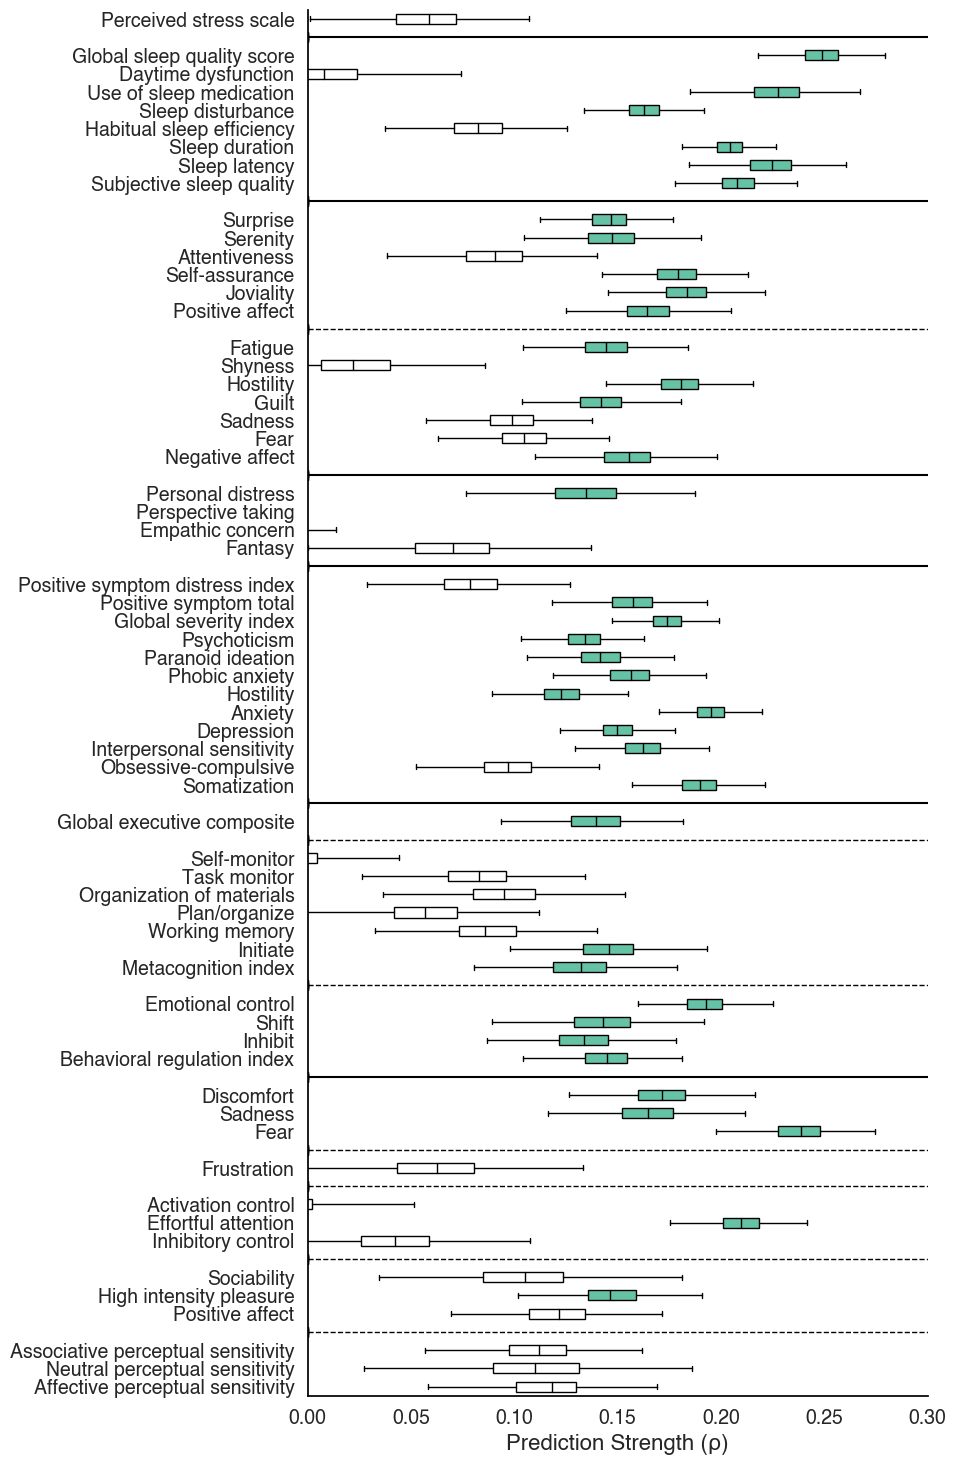

In [66]:
pred_file_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/symptom_predictions.mat'
header_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Symp_header_forplots.xlsx'
symp_table_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Symp_predictions_table.xlsx'

# Load the .mat file
pred_data = sio.loadmat(pred_file_path)

# Load the header and Symp_predictions_table.xlsx files
header = pd.read_excel(header_path)
symp_table = pd.read_excel(symp_table_path)

# Extract necessary data
p_vals_FDR = pred_data['p_vals_FDR'].flatten()  # Flatten in case it's a 2D array
predictions = pred_data['predictions']

headers_plot = header.columns.tolist()

# Remove the parenthesis content in 'headers_plot'
headers_plot_cleaned = [header.split('(')[0].strip() for header in headers_plot]

# Sort headers_plot_cleaned based on the order of 'Measures' in symp_table 
measures_order = symp_table['Measure'].tolist()
sort_indices = [headers_plot_cleaned.index(measure) for measure in measures_order if measure in headers_plot_cleaned]
assessments = symp_table['Assessment'].tolist()
domain = symp_table['Domain'].tolist()

# Sort all relevant arrays based on the new order
headers_plot_sorted = [headers_plot_cleaned[i] for i in sort_indices]
preds_plot_sorted = [predictions[:,i] for i in sort_indices]
p_vals_FDR_sorted = [p_vals_FDR[i] for i in sort_indices]

headers_plot_sorted_final = [item[:-2] if item.endswith("2") else item for item in headers_plot_sorted]

meds = np.median(preds_plot_sorted,axis=1)
order = np.argsort(-meds)
ranks = order.argsort()

# Create the figure
plt.figure(figsize=(8, 18))

# Calculate positions for staggering
positions = np.arange(len(headers_plot_sorted_final)) + 1

ax = plt.gca()

# Add horizontal lines between assessments and domains
last_assessment = assessments[0]
last_domain = domain[0]

for i in range(1, len(positions)):
    if assessments[i] != last_assessment:
        positions[i:] = positions[i:] + 1
        
        preds_plot_sorted = np.insert(preds_plot_sorted, positions[i-1], 0, axis=0)
        
        p_vals_FDR_sorted = np.insert(p_vals_FDR_sorted, positions[i-1], 1, axis=0)
        ax.axhline(y=positions[i] - 1, color='black', linestyle='-', linewidth=1.5)
        last_assessment = assessments[i]
        last_domain = domain[i]  # Reset domain when assessment changes
        
    elif domain[i] != last_domain:
        positions[i:] = positions[i:] + 1
        
        preds_plot_sorted = np.insert(preds_plot_sorted, positions[i-1], 0, axis=0)
            
        p_vals_FDR_sorted = np.insert(p_vals_FDR_sorted, positions[i-1], 1, axis=0)
        
        ax.axhline(y=positions[i] - 1, color='black', linestyle='--', linewidth=1.0)
        last_domain = domain[i]

preds_plot_sorted_final = [preds_plot_sorted[i,:] for i in range(len(preds_plot_sorted))]

# Create boxplots with conditional coloring
bp = ax.boxplot(preds_plot_sorted_final, widths=0.55, vert=False, patch_artist=True, sym='')

for ii, median in enumerate(bp['medians']):
    if p_vals_FDR_sorted[ii] < 0.05:
        # Set the box to white if p-value is less than 0.05
        bp['boxes'][ii].set_facecolor('#66c2a5')
    else:
        # Set the box to teal otherwise
        bp['boxes'][ii].set_facecolor('white')
    median.set_color('black')
    
    
# Set y-axis labels from headers
plt.yticks(ticks=positions, labels=headers_plot_sorted_final, fontsize=14)

# Set y-axis label and title
plt.xlabel('Prediction Strength (ρ)', fontsize=16)
plt.xlim(0, 0.3)
plt.xticks(fontsize=14)

sns.set(font='Helvetica')

ax.set_facecolor('white')
ax.figure.set_facecolor('white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.xaxis.set_tick_params(width=1, color='black')
ax.yaxis.set_tick_params(width=1, color='black')

# Show the plot
plt.grid(False)
plt.show()

# Figure 2

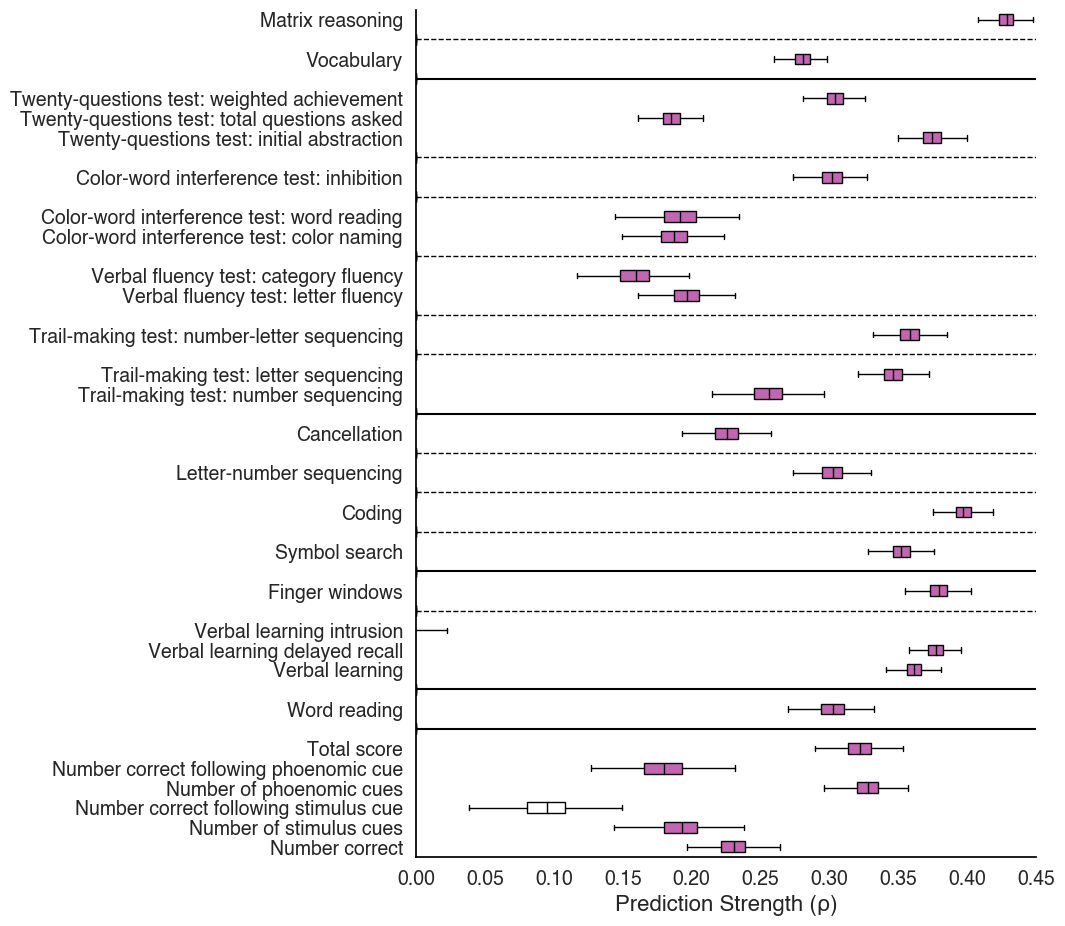

In [67]:
del pred_data, header, p_vals_FDR, predictions, headers_plot, headers_plot_cleaned

pred_file_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/cognitive_predictions.mat'
header_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Cog_header_forplots.xlsx'
cog_table_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Cog_predictions_table.xlsx'

pred_data = sio.loadmat(pred_file_path)

# Load the header and Symp_predictions_table.xlsx files
header = pd.read_excel(header_path)
cog_table = pd.read_excel(cog_table_path)

# Extract necessary data
p_vals_FDR = pred_data['p_vals_FDR'].flatten()  # Flatten in case it's a 2D array
predictions = pred_data['predictions']

headers_plot = header.columns.tolist()

# Remove the parenthesis content in 'headers_plot'
headers_plot_cleaned = [header.split('(')[0].strip() for header in headers_plot]

# Sort headers_plot_cleaned based on the order of 'Measures' in symp_table
measures_order = cog_table['Measure'].tolist()
sort_indices = [headers_plot_cleaned.index(measure) for measure in measures_order if measure in headers_plot_cleaned]
assessments = cog_table['Assessment'].tolist()
domain = cog_table['Domain'].tolist()

# Sort all relevant arrays based on the new order
headers_plot_sorted = [headers_plot_cleaned[i] for i in sort_indices]
preds_plot_sorted = [predictions[:,i] for i in sort_indices]
p_vals_FDR_sorted = [p_vals_FDR[i] for i in sort_indices]

# Create the figure
plt.figure(figsize=(8, 11))

# Calculate positions for staggering
positions = np.arange(len(headers_plot_sorted)) + 1

ax = plt.gca()

# Add horizontal lines between assessments and domains
last_assessment = assessments[0]
last_domain = domain[0]

for i in range(1, len(positions)):
    if assessments[i] != last_assessment:
        positions[i:] = positions[i:] + 1
        
        preds_plot_sorted = np.insert(preds_plot_sorted, positions[i-1], 0, axis=0)
        
        p_vals_FDR_sorted = np.insert(p_vals_FDR_sorted, positions[i-1], 1, axis=0)
        ax.axhline(y=positions[i] - 1, color='black', linestyle='-', linewidth=1.5)
        last_assessment = assessments[i]
        last_domain = domain[i]  # Reset domain when assessment changes
        
    elif domain[i] != last_domain:
        positions[i:] = positions[i:] + 1
        
        preds_plot_sorted = np.insert(preds_plot_sorted, positions[i-1], 0, axis=0)
            
        p_vals_FDR_sorted = np.insert(p_vals_FDR_sorted, positions[i-1], 1, axis=0)
        
        ax.axhline(y=positions[i] - 1, color='black', linestyle='--', linewidth=1.0)
        last_domain = domain[i]
        
# positions[1:] = positions[1:]-1
# preds_plot_sorted = np.delete(preds_plot_sorted, (1), axis=0)

preds_plot_sorted_final = [preds_plot_sorted[i,:] for i in range(len(preds_plot_sorted))]

# Create boxplots with conditional coloring
bp = ax.boxplot(preds_plot_sorted_final, widths=0.55, vert=False, patch_artist=True, sym='')

for ii, median in enumerate(bp['medians']):
    if p_vals_FDR_sorted[ii] < 0.05:
        # Set the box to white if p-value is less than 0.05
        bp['boxes'][ii].set_facecolor('#c266b1')
    else:
        # Set the box to teal otherwise
        bp['boxes'][ii].set_facecolor('white')
    median.set_color('black')
    
    
# Set y-axis labels from headers
plt.yticks(ticks=positions, labels=headers_plot_sorted, fontsize=14)

# Set y-axis label and title
plt.xlabel('Prediction Strength (ρ)', fontsize=16)
plt.xlim(0, 0.45)
plt.xticks(fontsize=14)

sns.set(font='Helvetica')

ax.set_facecolor('white')
ax.figure.set_facecolor('white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.xaxis.set_tick_params(width=1, color='black')
ax.yaxis.set_tick_params(width=1, color='black')

# Show the plot
plt.grid(False)
plt.show()

# Figure 3

In [74]:
pred_file_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/symptom_predictions.mat'
header_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Symp_header_forplots.xlsx'
symp_table_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Symp_predictions_table.xlsx'
sympdata_raw = sio.loadmat('/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_input_data/sympdata_to_model.mat')

pred_data = sio.loadmat(pred_file_path)

# Load the header and Symp_predictions_table.xlsx files
header = pd.read_excel(header_path)
symp_table = pd.read_excel(symp_table_path)

# Extract necessary data
p_vals_FDR = pred_data['p_vals_FDR'].flatten()  # Flatten in case it's a 2D array
predictions = pred_data['predictions']

headers_plot = header.columns.tolist()

# Remove the parenthesis content in 'headers_plot'
headers_plot_cleaned = [header.split('(')[0].strip() for header in headers_plot]

measures_order = symp_table['Measure'].tolist()
sort_indices = [headers_plot_cleaned.index(measure) for measure in measures_order if measure in headers_plot_cleaned]
assessments = symp_table['Assessment'].tolist()
domain = symp_table['Domain'].tolist()

# Sort all relevant arrays based on the new order
headers_plot_sorted = [headers_plot_cleaned[i] for i in sort_indices]
preds_plot_sorted = [predictions[:,i] for i in sort_indices]
p_vals_FDR_sorted = [p_vals_FDR[i] for i in sort_indices]

headers_plot_sorted_final = [item[:-2] if item.endswith("2") else item for item in headers_plot_sorted]

category_symp = [1,1,1,2,2,2,3,3,3,4,5,5,5,6,6,6,6,7,7,7,7,7,7,7,8,9,9,9,9,9,9,9,9,9,9,9,9,10,10,10,10,11,11,11,11,11,11,11,12,12,12,12,12,12,13,13,13,13,13,13,13,13,14]
labels = ['ATQ: orienting \nsensitivity','ATQ: extraversion/\nsurgency','ATQ: effortful \ncontrol','ATQ: aggressive \nnegative affect','ATQ: non-aggressive \nnegative affect','BRIEF: behavioral \nregulation','BRIEF: metacognition','BRIEF: global \nexecutive composite','BSI','IRI','PANAS: negative','PANAS: positive','PSQI','PSS']

category_symp = np.array(category_symp)

preds_matrix = np.column_stack(preds_plot_sorted)  # Convert list of arrays to a matrix (1000x63)

In [80]:
# --- One-way ANOVA ---
unique_categories = np.unique(category_symp)

# Correctly group prediction strengths by category using preds_matrix
grouped_data = [
    preds_matrix[:, category_symp == cat].flatten() for cat in unique_categories
]

# Run ANOVA test
anova_result = stats.f_oneway(*grouped_data)
print(f"ANOVA Results: F={anova_result.statistic:.4f}, p={anova_result.pvalue:.10e}")

# Compute degrees of freedom
k = len(grouped_data)  # Number of groups
N = sum(len(group) for group in grouped_data)  # Total number of observations

df_between = k - 1  # Degrees of freedom between groups
df_within = N - k   # Degrees of freedom within groups

print(f"F-statistic: {anova_result.statistic}")
print(f"p-value: {anova_result.pvalue}")
print(f"DF Between: {df_between}, DF Within: {df_within}")

# Calculate effect size
all_data = np.concatenate(grouped_data)
grand_mean = np.mean(all_data)

# Sums of squares
SS_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in grouped_data)
SS_within  = sum(np.sum((g - np.mean(g)) ** 2) for g in grouped_data)
SS_total   = SS_between + SS_within

# Mean square within
MS_within = SS_within / df_within

# Eta-squared (proportion of total variance explained)
eta_sq = SS_between / SS_total

# Cohen's f (from eta^2)
cohens_f = np.sqrt(eta_sq / (1 - eta_sq)) if eta_sq < 1 else np.inf

print(f"Cohen's f: {cohens_f:.4f}")

ANOVA Results: F=3059.9758, p=0.0000000000e+00
F-statistic: 3059.975846815184
p-value: 0.0
DF Between: 13, DF Within: 62986
Cohen's f: 0.7947


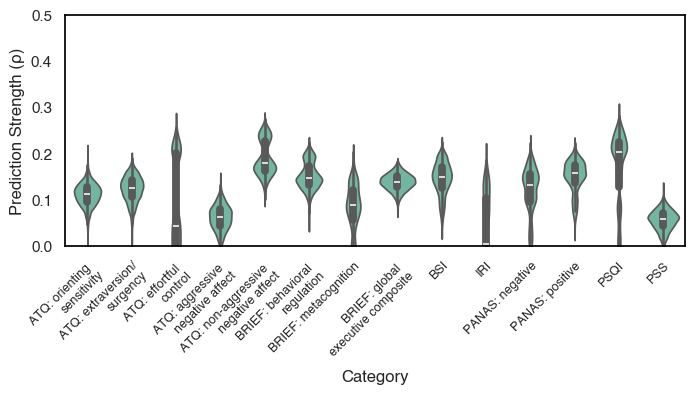

In [81]:
data_list = []

for var_idx in range(preds_matrix.shape[1]):  # Loop over variables (columns)
    category = category_symp[var_idx]  # Get category of the variable
    for case_idx in range(preds_matrix.shape[0]):  # Loop over cases (rows)
        data_list.append([preds_matrix[case_idx, var_idx], category])

# Convert to DataFrame
df = pd.DataFrame(data_list, columns=["Prediction Strength", "Category"])

# Convert Category to string for better visualization
df["Category"] = df["Category"].astype(str)

# Create the violin plot
positions = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(x="Category", y="Prediction Strength", data=df,color='#66c2a5')
plt.ylabel("Prediction Strength (ρ)")
plt.xticks(ticks=positions, labels=labels, fontsize=9,rotation=45, ha='right', rotation_mode='anchor')

plt.ylim([0,0.5])
ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')
    
plt.show()

In [82]:
ICC_raw = pred_data['ICC']  

sympdata = sympdata_raw['sympdata']

medians = np.median(predictions, axis=0)

data = np.zeros((317,63))

rows = sympdata.shape[0]
cols = sympdata.shape[1]

ICC = np.zeros(len(ICC_raw))
for r in range(len(ICC_raw)):
    ICC[r] = ICC_raw[r][0]

for r in range(rows):
    for c in range(cols):
        data[r,c] = sympdata[r,c][0][0]
        
variance = np.zeros((cols))
kurt = np.zeros((cols))
skwn = np.zeros((cols))

# Calculate distribution statistics
for c in range(cols):
    vector = data[:,c][~np.isnan(data[:,c])]
    zvec = zscore(vector)
    variance[c] = np.var(vector,ddof=1)  # Use ddof=1 for sample variance
    skwn[c] = skew(data[:,c],nan_policy='omit')
    
    
valid_indices = ~np.isnan(medians) & ~np.isnan(variance)
var_r, var_p = pearsonr(medians[valid_indices], variance[valid_indices])

valid_indices = ~np.isnan(medians) & ~np.isnan(skwn)
skwn_r, skwn_p = pearsonr(medians[valid_indices], skwn[valid_indices])

valid_indices = ~np.isnan(medians) & ~np.isnan(ICC)
ICC_r, ICC_p = pearsonr(medians[valid_indices], ICC[valid_indices])
    
print(ICC_r)
print(skwn_r)
print(var_r)

0.02555941071379588
0.0716234084327355
0.032271797270882176


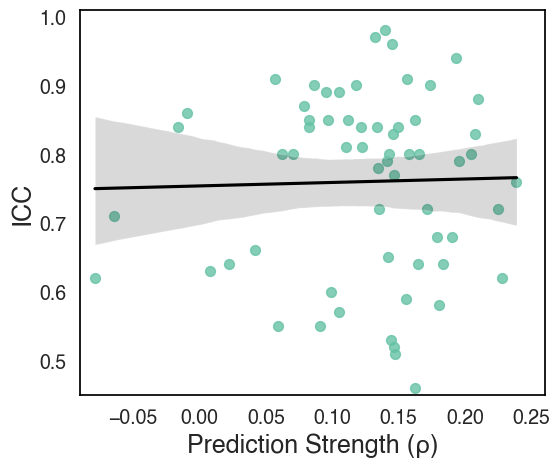

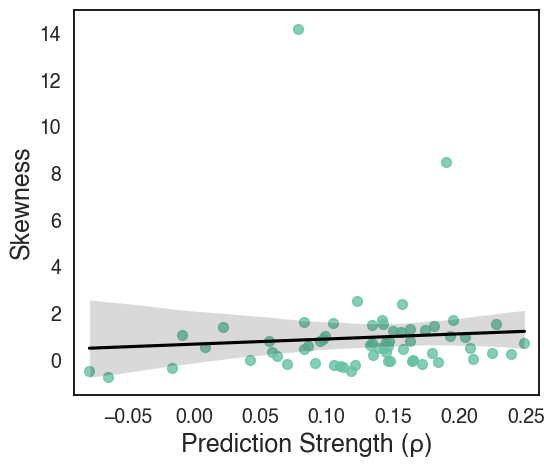

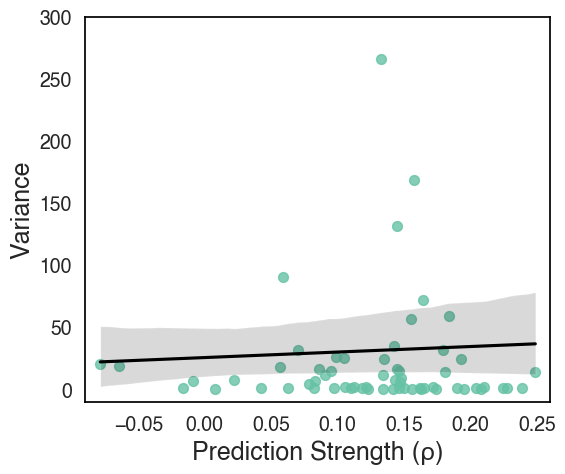

In [83]:
# Create a scatter plot with a fit line and shaded confidence intervals
plt.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=medians, y=ICC, ci=95, scatter_kws={'s': 50}, line_kws={'color': 'black'},color='#66c2a5')  #teal

# Add labels and title
plt.xlabel('Prediction Strength (ρ)', fontsize=18)
plt.ylabel('ICC', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(-.09, 0.26)
plt.ylim(0.45, 1.01)

ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')

plt.show()

######
plt.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=medians, y=skwn, ci=95, scatter_kws={'s': 50}, line_kws={'color': 'black'},color='#66c2a5')  #teal

# Add labels and title
plt.xlabel('Prediction Strength (ρ)', fontsize=18)
plt.ylabel('Skewness', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(-.09, 0.26)
plt.ylim(-1.5, 15)

ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')

plt.show()

######
plt.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=medians, y=variance, ci=95, scatter_kws={'s': 50}, line_kws={'color': 'black'},color='#66c2a5')  #teal

# Add labels and title
plt.xlabel('Prediction Strength (ρ)', fontsize=18)
plt.ylabel('Variance', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(-.09, 0.26)
plt.ylim(-10, 300)

ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')

plt.show()

In [84]:
pred_file_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/cognitive_predictions.mat'
header_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Cog_header_forplots.xlsx'
cog_table_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Cog_predictions_table.xlsx'
cogdata_raw = sio.loadmat('/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_input_data/cogdata_to_model.mat')

pred_data = sio.loadmat(pred_file_path)

# Load the header and Symp_predictions_table.xlsx files
header = pd.read_excel(header_path)
cog_table = pd.read_excel(cog_table_path)

# Extract necessary data
p_vals_FDR = pred_data['p_vals_FDR'].flatten()  # Flatten in case it's a 2D array
predictions = pred_data['predictions']

headers_plot = header.columns.tolist()

# Remove the parenthesis content in 'headers_plot'
headers_plot_cleaned = [header.split('(')[0].strip() for header in headers_plot]

measures_order = cog_table['Measure'].tolist()
sort_indices = [headers_plot_cleaned.index(measure) for measure in measures_order if measure in headers_plot_cleaned]

# Sort all relevant arrays based on the new order
headers_plot_sorted = [headers_plot_cleaned[i] for i in sort_indices]
preds_plot_sorted = [predictions[:,i] for i in sort_indices]
p_vals_FDR_sorted = [p_vals_FDR[i] for i in sort_indices]

headers_plot_sorted_final = [item[:-2] if item.endswith("2") else item for item in headers_plot_sorted]

category_cog = [1,1,1,1,1,1,2,3,3,3,4,5,6,7,8,9,9,9,10,10,11,11,11,12,12,12,13,14]
labels = ['BNT',
          'WRAT',
          'WRAML: verbal \nlearning',
          'WRAML: finger \nwindows',
          'WAIS: symbol search',
          'WAIS: coding',
          'WAIS: letter-number \nsequencing',
          'WAIS: cancellation',
          'D-KEFS: trail \nmaking',
          'D-KEFS: verbal \nfluency',
          'D-KEFS: color-word \ninterference',
          'D-KEFS: 20 \nquestions',
          'WASI: vocabulary',
          'WASI: matrix \nreasoning'
          ]

preds_matrix = np.column_stack(preds_plot_sorted) 

In [85]:
# --- One-way ANOVA ---
unique_categories = np.unique(category_cog)

# Correctly group prediction strengths by category using preds_matrix
grouped_data = [
    preds_matrix[:, category_cog == cat].flatten() for cat in unique_categories
]

# Run ANOVA test
anova_result = stats.f_oneway(*grouped_data)
print(f"ANOVA Results: F={anova_result.statistic:.4f}, p={anova_result.pvalue:.10e}")

# Compute degrees of freedom
k = len(grouped_data)  # Number of groups
N = sum(len(group) for group in grouped_data)  # Total number of observations

df_between = k - 1  # Degrees of freedom between groups
df_within = N - k   # Degrees of freedom within groups

print(f"F-statistic: {anova_result.statistic}")
print(f"p-value: {anova_result.pvalue}")
print(f"DF Between: {df_between}, DF Within: {df_within}")

# Calculate effect size
all_data = np.concatenate(grouped_data)
grand_mean = np.mean(all_data)

# Sums of squares
SS_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in grouped_data)
SS_within  = sum(np.sum((g - np.mean(g)) ** 2) for g in grouped_data)
SS_total   = SS_between + SS_within

# Mean square within
MS_within = SS_within / df_within

# Eta-squared (proportion of total variance explained)
eta_sq = SS_between / SS_total

# Cohen's f (from eta^2)
cohens_f = np.sqrt(eta_sq / (1 - eta_sq)) if eta_sq < 1 else np.inf

print(f"Cohen's f: {cohens_f:.4f}")

ANOVA Results: F=1194.9635, p=0.0000000000e+00
F-statistic: 1194.963497131401
p-value: 0.0
DF Between: 13, DF Within: 27986
Cohen's f: 0.7450


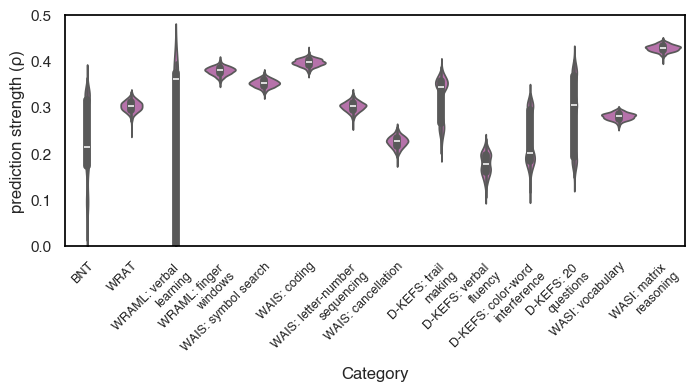

In [63]:
data_list = []

for var_idx in range(preds_matrix.shape[1]):  # Loop over variables (columns)
    category = category_cog[var_idx]  # Get category of the variable
    for case_idx in range(preds_matrix.shape[0]):  # Loop over cases (rows)
        data_list.append([preds_matrix[case_idx, var_idx], category])
        
df = pd.DataFrame(data_list, columns=["Prediction Strength", "Category"])

# Convert Category to string for better visualization
df["Category"] = df["Category"].astype(str)

# Create the violin plot
positions = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(x="Category", y="Prediction Strength", data=df,color='#c266b1')
plt.ylabel("Prediction Strength (ρ)")
plt.xticks(ticks=positions, labels=labels, fontsize=9,rotation=45, ha='right', rotation_mode='anchor')

plt.ylim([0,0.5])
ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')
    
plt.show()

In [64]:
ICC_raw = pred_data['ICC']  

cogdata = cogdata_raw['cogdata']

medians = np.median(predictions, axis=0)

data = np.zeros((317,63))

rows = cogdata.shape[0]
cols = cogdata.shape[1]

ICC = np.zeros(len(ICC_raw))
for r in range(len(ICC_raw)):
    ICC[r] = ICC_raw[r][0]

for r in range(rows):
    for c in range(cols):
        data[r,c] = cogdata[r,c][0][0]
        
variance = np.zeros((cols))
kurt = np.zeros((cols))
skwn = np.zeros((cols))

# Calculate distribution statistics
for c in range(cols):
    vector = data[:,c][~np.isnan(data[:,c])]
    zvec = zscore(vector)
    variance[c] = np.var(vector,ddof=1)  # Use ddof=1 for sample variance
    skwn[c] = skew(data[:,c],nan_policy='omit')
    
    
valid_indices = ~np.isnan(medians) & ~np.isnan(variance)
var_r, var_p = pearsonr(medians[valid_indices], variance[valid_indices])

valid_indices = ~np.isnan(medians) & ~np.isnan(skwn)
skwn_r, skwn_p = pearsonr(medians[valid_indices], skwn[valid_indices])

valid_indices = ~np.isnan(medians) & ~np.isnan(ICC)
ICC_r, ICC_p = pearsonr(medians[valid_indices], ICC[valid_indices])
    
print(ICC_r)
print(skwn_r)
print(var_r)

-0.12168885659604897
-0.4557046527868137
0.26228586898244444


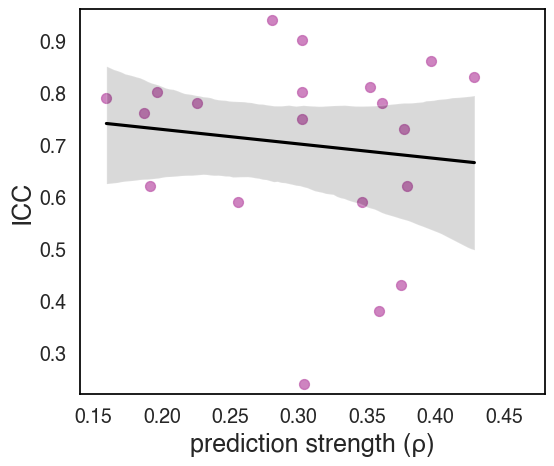

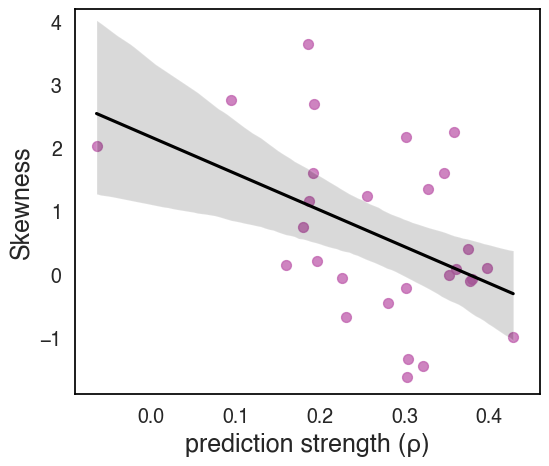

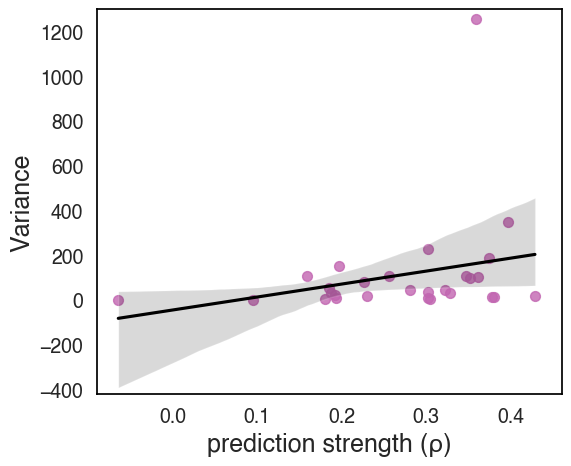

In [65]:
# Create a scatter plot with a fit line and shaded confidence intervals
plt.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=medians, y=ICC, ci=95, scatter_kws={'s': 50}, line_kws={'color': 'black'},color='#c266b1')  #purp

# Add labels and title
plt.xlabel('Prediction Strength (ρ)', fontsize=18)
plt.ylabel('ICC', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(0.14, 0.48)
plt.ylim(0.22, 0.96)

ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')

plt.show()

######
plt.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=medians, y=skwn, ci=95, scatter_kws={'s': 50}, line_kws={'color': 'black'},color='#c266b1')  #purp

# Add labels and title
plt.xlabel('Prediction Strength (ρ)', fontsize=18)
plt.ylabel('Skewness', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(-.09, 0.46)
plt.ylim(-1.9, 4.2)

ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')

plt.show()

######
plt.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=medians, y=variance, ci=95, scatter_kws={'s': 50}, line_kws={'color': 'black'},color='#c266b1')  #purp

# Add labels and title
plt.xlabel('Prediction Strength (ρ)', fontsize=18)
plt.ylabel('Variance', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(-.09, 0.46)
plt.ylim(-420, 1300)

ax.set_facecolor('white')  # Set background of the plot to white

for spine in ax.spines.values():
    spine.set_color('black')

plt.show()

# Figure 4

In [18]:
# Load symptom data
sympdata_raw = sio.loadmat('/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_input_data/sympdata_to_model.mat')

# Load symptom predictions
pred_file_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/symptom_predictions.mat'
pred_data = sio.loadmat(pred_file_path)

# Load the header file
header_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Symp_header_forplots.xlsx'
symp_header = pd.read_excel(header_path)

connectomes_file = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_input_data/averaged_mats.mat'
connectomes = sio.loadmat(connectomes_file)['avg_mats']

sympdata = sympdata_raw['sympdata']

rows = sympdata.shape[0]
cols = sympdata.shape[1]

symp_data = np.zeros((317,63))
for r in range(rows):
    for c in range(cols):
        symp_data[r,c] = sympdata[r,c][0][0]
        
# Convert to a dataframe 
df_temp = pd.DataFrame(symp_data, columns=symp_header.columns)

# Combine the DataFrame with headers 
symp_data_df = pd.concat([symp_header, df_temp], ignore_index=True)
        
# Identify significant predictions
p_vals_FDR = pred_data['p_vals_FDR'].squeeze()  # Flatten the array if necessary

sig_ix = p_vals_FDR < 0.05

symp_headers_list = list(symp_header.columns)

sig_symp_headers = [symp_headers_list[i] for i, is_sig in enumerate(sig_ix) if is_sig]

df_symp_data_sig = symp_data_df.loc[:, sig_ix]

# Rename measures with duplicate names that were initially saved with a 2 at the end to indicate they were duplicates
df_symp_data_sig.rename(columns={'Hostility 2 (PANAS)': 'Hostility (PANAS)'}, inplace=True)
df_symp_data_sig.rename(columns={'Sadness 2 (ATQ)': 'Sadness (ATQ)'}, inplace=True)
df_symp_data_sig.rename(columns={'Fear 2 (ATQ)': 'Fear (ATQ)'}, inplace=True)
        
symp_networks = pred_data['networks']

# Extract both positive and negative CPM networks
netfields_both = [field for field in symp_networks[0, 0].dtype.names if field.endswith('_both')]
netdata_both = {field: symp_networks[0, 0][field].squeeze() for field in netfields_both}

# Create a pandas DataFrame for the extracted data
df_symp_networks = pd.DataFrame(netdata_both)

####### Extract positive CPM networks #######
netfields_pos = [field for field in symp_networks[0, 0].dtype.names if field.endswith('_pos')]
netdata_pos = {field: symp_networks[0, 0][field].squeeze() for field in netfields_pos}

# Create a pandas DataFrame for the extracted data
df_symp_networks_pos = pd.DataFrame(netdata_pos)


####### Extract negative CPM networks #######
netfields_neg = [field for field in symp_networks[0, 0].dtype.names if field.endswith('_neg')]
netdata_neg = {field: symp_networks[0, 0][field].squeeze() for field in netfields_neg}

# Create a pandas DataFrame for the extracted data
df_symp_networks_neg = pd.DataFrame(netdata_neg)


####### Filter based on significance #######
df_symp_networks_sig = df_symp_networks.loc[:, sig_ix]
df_symp_networks_sig.columns = sig_symp_headers

df_PosSymp_networks_sig = df_symp_networks_pos.loc[:, sig_ix]
df_PosSymp_networks_sig.columns = sig_symp_headers

df_NegSymp_networks_sig = df_symp_networks_neg.loc[:, sig_ix]
df_NegSymp_networks_sig.columns = sig_symp_headers

df_PosSymp_networks_sig.rename(columns={'Hostility 2 (PANAS)': 'Hostility (PANAS)'}, inplace=True)
df_PosSymp_networks_sig.rename(columns={'Sadness 2 (ATQ)': 'Sadness (ATQ)'}, inplace=True)
df_PosSymp_networks_sig.rename(columns={'Fear 2 (ATQ)': 'Fear (ATQ)'}, inplace=True)

df_NegSymp_networks_sig.rename(columns={'Hostility 2 (PANAS)': 'Hostility (PANAS)'}, inplace=True)
df_NegSymp_networks_sig.rename(columns={'Sadness 2 (ATQ)': 'Sadness (ATQ)'}, inplace=True)
df_NegSymp_networks_sig.rename(columns={'Fear 2 (ATQ)': 'Fear (ATQ)'}, inplace=True)

/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_50492/4158123367.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_symp_data_sig.rename(columns={'Hostility 2 (PANAS)': 'Hostility (PANAS)'}, inplace=True)
/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_50492/4158123367.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_symp_data_sig.rename(columns={'Sadness 2 (ATQ)': 'Sadness (ATQ)'}, inplace=True)
/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_50492/4158123367.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats i

In [19]:
# Function to calculate the Dice coefficient
def dice_coefficient(column1, column2):
    intersection = np.sum(column1 & column2)
    size1 = np.sum(column1)
    size2 = np.sum(column2)
    return (2 * intersection) / (size1 + size2) if (size1 + size2) > 0 else 0

In [20]:
cogdata_raw = sio.loadmat('/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_input_data/cogdata_to_model.mat')

# Load cognitive predictions
pred_file_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/cognitive_predictions.mat'
pred_data = sio.loadmat(pred_file_path)

# Load the header file
header_path = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/CPM_output/Cog_header_forplots.xlsx'
cog_header = pd.read_excel(header_path)

cogdata = cogdata_raw['cogdata']

rows = cogdata.shape[0]
cols = cogdata.shape[1]

cog_data = np.zeros((317,28))
for r in range(rows):
    for c in range(cols):
        cog_data[r,c] = cogdata[r,c][0][0]
        
# Convert to a dataframe 
cog_data_df = pd.DataFrame(cog_data, columns=cog_header.columns)

# Identify significant predictions
p_vals_FDR = pred_data['p_vals_FDR'].squeeze()  # Flatten the array if necessary

sig_ix = p_vals_FDR < 0.05

cog_headers_list = list(cog_header.columns)

sig_cog_headers = [cog_headers_list[i] for i, is_sig in enumerate(sig_ix) if is_sig]

df_cog_data_sig = cog_data_df.loc[:, sig_ix]

cog_networks = pred_data['networks']

# Extract both positive and negative CPM networks
netfields_both = [field for field in cog_networks[0, 0].dtype.names if field.endswith('_both')]
netdata_both = {field: cog_networks[0, 0][field].squeeze() for field in netfields_both}

# Create a pandas DataFrame for the extracted data
df_cog_networks = pd.DataFrame(netdata_both)


####### Extract positive CPM networks #######
netfields_pos = [field for field in cog_networks[0, 0].dtype.names if field.endswith('_pos')]
netdata_pos = {field: cog_networks[0, 0][field].squeeze() for field in netfields_pos}

# Create a pandas DataFrame for the extracted data
df_cog_networks_pos = pd.DataFrame(netdata_pos)


####### Extract negative CPM networks #######
netfields_neg = [field for field in cog_networks[0, 0].dtype.names if field.endswith('_neg')]
netdata_neg = {field: cog_networks[0, 0][field].squeeze() for field in netfields_neg}

# Create a pandas DataFrame for the extracted data
df_cog_networks_neg = pd.DataFrame(netdata_neg)


####### Filter based on significance #######
df_cog_networks_sig = df_cog_networks.loc[:, sig_ix]
df_cog_networks_sig.columns = sig_cog_headers

df_Poscog_networks_sig = df_cog_networks_pos.loc[:, sig_ix]
df_Poscog_networks_sig.columns = sig_cog_headers

df_Negcog_networks_sig = df_cog_networks_neg.loc[:, sig_ix]
df_Negcog_networks_sig.columns = sig_cog_headers

preds = pred_data['predictions']

In [21]:
# Combine raw clinical and cognitive scores and compute correlation matrix
df_data_combined = pd.concat([df_symp_data_sig, df_cog_data_sig], axis=1)

corrmat_combined = df_data_combined.corr(method='spearman')

### Convert FULL correlation matrix to dataframe to setup for FDR correction for multiple comparisons
n_meas = df_data_combined.shape[1]

corr_r = np.full((n_meas, n_meas), np.nan)
corr_p = np.full((n_meas, n_meas), np.nan)

# Compute Spearman correlations and p-values
for i, col in enumerate(df_data_combined.columns):
    for j, col1 in enumerate(df_data_combined.columns):
        # Compute correlation and p-value
        corr, pval = spearmanr(df_data_combined[col], df_data_combined[col1],nan_policy='omit')
        
        corr_r[i, j] = corr
        corr_p[i, j] = pval

# Convert to DataFrame for better visualization
corr_df = pd.DataFrame(corr_r, index=df_data_combined.columns, columns=df_data_combined.columns)
pval_df = pd.DataFrame(corr_p, index=df_data_combined.columns, columns=df_data_combined.columns)

# Flatten the p-value matrix and apply FDR correction
pvals_flat = pval_df.values.flatten()
_, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

cmap = plt.get_cmap('inferno_r')
colors = [
    (1, 1, 0),  # Bright yellow for p-value of 0
    cmap(0.5),  # Green-blue for p-value of 0.025
]
custom_cmap = LinearSegmentedColormap.from_list('inferno_r', colors, N=256)

# Reshape corrected p-values back into the original matrix shape
pval_corrected_matrix = pvals_corrected.reshape(pval_df.shape)
pval_corrected_df = pd.DataFrame(pval_corrected_matrix, index=df_data_combined.columns, columns=df_data_combined.columns)

# pval_corrected_significant = pval_corrected_df.where(pval_corrected_df < 0.05)
pval_corrected_df[pval_corrected_df > 0.05] = 1

cmap = plt.get_cmap('inferno_r')
colors = [
    (1, 1, 0),  # Bright yellow for p-value of 0
    cmap(0.5),  # Green-blue for p-value of 0.025
]
custom_cmap = LinearSegmentedColormap.from_list('inferno_r', colors, N=256)

# Mask p-values greater than 0.05 and set them to black
masked_pval = pval_corrected_df.copy()
masked_pval[pval_corrected_df > 0.05] = np.nan

In [22]:
del netfields_both, netdata_both, netdata_pos, netfields_pos, netfields_neg, netdata_neg

df_PosNets_combined = pd.concat([df_PosSymp_networks_sig, df_Poscog_networks_sig], axis=1)
df_NegNets_combined = pd.concat([df_NegSymp_networks_sig, df_Negcog_networks_sig], axis=1)

n_meas = df_NegNets_combined.shape[1]

p_value_matrix = np.zeros((n_meas, n_meas)) 
dice_matrix = np.zeros((n_meas,n_meas))
n_overlap = np.zeros((n_meas,n_meas))
netscore = np.zeros((n_meas,n_meas,connectomes.shape[2]))
degree_sympcog_z = np.zeros((n_meas,n_meas,268))

overlap_matrix = np.zeros((n_meas,n_meas,35778))

for i in range(n_meas):
    for j in range(n_meas):
                
        # if the correlation is positive, compare positive to positive and negative to negative CPM networks
        if corrmat_combined.iloc[i,j] > 0:
        
            # Compute dice coefficients and p-values
            pos_A = df_PosNets_combined.iloc[:, i]
            pos_B = df_PosNets_combined.iloc[:, j]

            dice_pos = dice_coefficient(pos_A, pos_B)

            # Compute dice coefficients and p-values
            neg_A = df_NegNets_combined.iloc[:, i]
            neg_B = df_NegNets_combined.iloc[:, j]

            dice_neg = dice_coefficient(neg_A, neg_B)
            
            # take the weighted average of the 2 dice coefficients
            overlap_pos = np.sum((pos_A == 1) & (pos_B == 1)) 
            overlap_neg = np.sum((neg_A == 1) & (neg_B == 1))
            
            overlap_pos_loc = np.where((pos_A == 1) & (pos_B == 1)) 
            overlap_neg_loc = np.where((neg_A == 1) & (neg_B == 1))

            # take the weighted average of the 2 dice coefficients
            dice = ((dice_pos * (np.sum(pos_A) + np.sum(pos_B))) + (dice_neg * (np.sum(neg_A) + np.sum(neg_B)))) / (np.sum(pos_A) + np.sum(pos_B) + np.sum(neg_A) + np.sum(neg_B))

            dice_matrix[i, j] = dice
        
            N = len(pos_A)
            
            k1 = np.sum(pos_A) + np.sum(neg_A)
            k2 = np.sum(pos_B) + np.sum(neg_B)
        
            overlap = overlap_pos + overlap_neg
            
            n_overlap[i,j] = overlap
            p_value_matrix[i,j] = hypergeom.sf(overlap - 1, N, k1, k2)
            
            # # loop through number of subjects and calculate network score for overlapping networks
            for s in range(connectomes.shape[2]):
                vect = connectomes[:,:,s][np.triu_indices(268, k=1)]

                # compute sum of edges at 'overlap_pos_loc' - sum of edges at 'overlap_neg_loc'
                netscore[i,j,s] = np.sum(vect[overlap_pos_loc[0]]) - np.sum(vect[overlap_neg_loc[0]])

                del vect

        elif corrmat_combined.iloc[i,j] < 0:
        
            # Compute dice coefficients 
            pos_A = df_PosNets_combined.iloc[:, i]
            neg_B = df_NegNets_combined.iloc[:, j]

            neg_A = df_NegNets_combined.iloc[:, i]
            pos_B = df_PosNets_combined.iloc[:, j]

            dice_pos = dice_coefficient(pos_A, neg_B)
            dice_neg = dice_coefficient(neg_A, pos_B)
            
            # take the weighted average of the 2 dice coefficients
            overlap_pos = np.sum((pos_A == 1) & (neg_B == 1)) 
            overlap_neg = np.sum((neg_A == 1) & (pos_B == 1))
            
            overlap_pos_loc = np.where((pos_A == 1) & (neg_B == 1)) 
            overlap_neg_loc = np.where((neg_A == 1) & (pos_B == 1))

            # take the weighted average of the 2 dice coefficients
            dice = ((dice_pos * (np.sum(pos_A) + np.sum(neg_B))) + (dice_neg * (np.sum(neg_A) + np.sum(pos_B)))) / (np.sum(pos_A) + np.sum(pos_B) + np.sum(neg_A) + np.sum(neg_B))

            dice_matrix[i, j] = dice
        
            N = len(pos_A)
            
            k1 = np.sum(pos_A) + np.sum(neg_A)
            k2 = np.sum(pos_B) + np.sum(neg_B)
        
            overlap = overlap_pos + overlap_neg
            
            n_overlap[i,j] = overlap
            p_value_matrix[i,j] = hypergeom.sf(overlap - 1, N, k1, k2)
            
             # # loop through number of subjects and calculate network score for overlapping networks
            for s in range(connectomes.shape[2]):
                vect = connectomes[:,:,s][np.triu_indices(268, k=1)]

                # compute sum of edges at 'overlap_pos_loc' - sum of edges at 'overlap_neg_loc'
                netscore[i,j,s] = np.sum(vect[overlap_pos_loc[0]]) - np.sum(vect[overlap_neg_loc[0]])

                del vect
            
        # Store info about where the nodes are that have the most overlap between symptoms and cognition
        overlapping_edges = np.zeros((35778))  # make 35778 vector of 0s and put ones in overlap positions

        overlapping_edges[overlap_pos_loc] = 1
        overlapping_edges[overlap_neg_loc] = 1
        
        overlap_matrix[i,j,:] = overlapping_edges
        
        mat = np.zeros((268,268))

        ix = -1

        for r in range(268):
            for c in range(268):
                if r < c:
                    ix=ix+1
                    mat[r,c] = overlapping_edges[ix]
                elif r == c:
                    mat[r,c] = 0

        mat = mat + mat.T

        degree_sympcog = np.sum(mat, axis=1)
        degree_sympcog_z[i,j,:] = stats.zscore(degree_sympcog)
        
        del degree_sympcog, mat, overlapping_edges, overlap_pos_loc, overlap_neg_loc

In [24]:
# Convert results to DataFrames
dice_df = pd.DataFrame(dice_matrix, index=df_PosNets_combined.columns, columns=df_PosNets_combined.columns)
pval_df_brain = pd.DataFrame(p_value_matrix, index=df_PosNets_combined.columns, columns=df_PosNets_combined.columns)
n_overlap_df = pd.DataFrame(n_overlap, index=df_PosNets_combined.columns, columns=df_PosNets_combined.columns)

# Use ward's method for clustering
dice_matrix = dice_df.values  # If it's a DataFrame; else use dice_matrix = dice_df
distance_matrix = 1 - dice_matrix

condensed_distance = sch.distance.squareform(distance_matrix)

# Perform hierarchical clustering using Ward's method
linkage_matrix = sch.linkage(condensed_distance, method='ward')

# Get the order of the measures from linkage_matrix
dendro = sch.dendrogram(linkage_matrix, no_plot=True)
sorted_ixs = dendro['leaves'][::-1]

# Reorder rows and columns of dice_df
sorted_lbls = dice_df.index[sorted_ixs]
sorted_dice_df = dice_df.loc[sorted_lbls, sorted_lbls]

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/threadpoolctl.py:1019: RuntimeWarning: libc not found. The ctypes module in Python 3.8 is maybe too old for this OS.
  warnings.warn(


Optimal number of clusters using the elbow method: 9


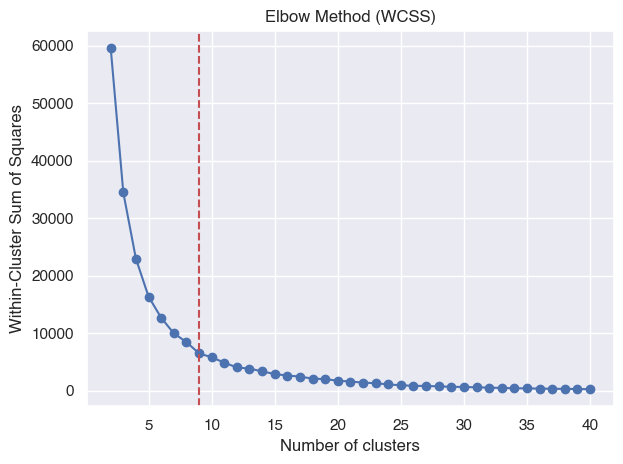

In [25]:
# Determine an appropriate number of clusters using the elbow method
max_clusters = 40
    
def compute_elbow(X, k_max):
    sse = []
    for k in range(2, k_max + 1):  # Start from k=2
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
        sse.append(kmeans.inertia_)
    return sse

elbow_sse = compute_elbow(linkage_matrix, max_clusters)
# Use KneeLocator to find the "elbow"
kneedle = KneeLocator(range(2, max_clusters + 1), elbow_sse, curve="convex", direction="decreasing")
optimal_k_elbow = kneedle.elbow
print(f"Optimal number of clusters using the elbow method: {optimal_k_elbow}")

# plt.plot(range(2, max_clusters + 1), wcss, marker='o')
plt.plot(range(2, max_clusters + 1), elbow_sse, marker='o')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of clusters')
plt.axvline(optimal_k_elbow, color='r', linestyle='--', label=f'Optimal k={optimal_k_elbow}')
plt.ylabel('Within-Cluster Sum of Squares')
plt.tight_layout()
plt.show()

/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_50492/4274771141.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


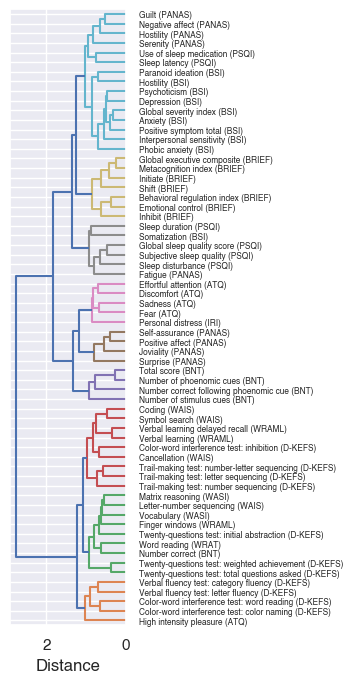

In [27]:
# # Plot dendrogram
# reverse leaf order
dendro = sch.dendrogram(
    linkage_matrix,
    no_plot=True
)

reversed_leaves = dendro['leaves'][::-1]
reversed_label_map = {leaf: dice_df.index[leaf] for leaf in reversed_leaves}

plt.figure(figsize=(1.5, 8))
sch.dendrogram(
    linkage_matrix,
    orientation='left',
    color_threshold=linkage_matrix[-8, 2],
    leaf_rotation=0,
    leaf_label_func=lambda id: reversed_label_map[id]
)

plt.xlabel('Distance')
plt.tight_layout()
plt.show()

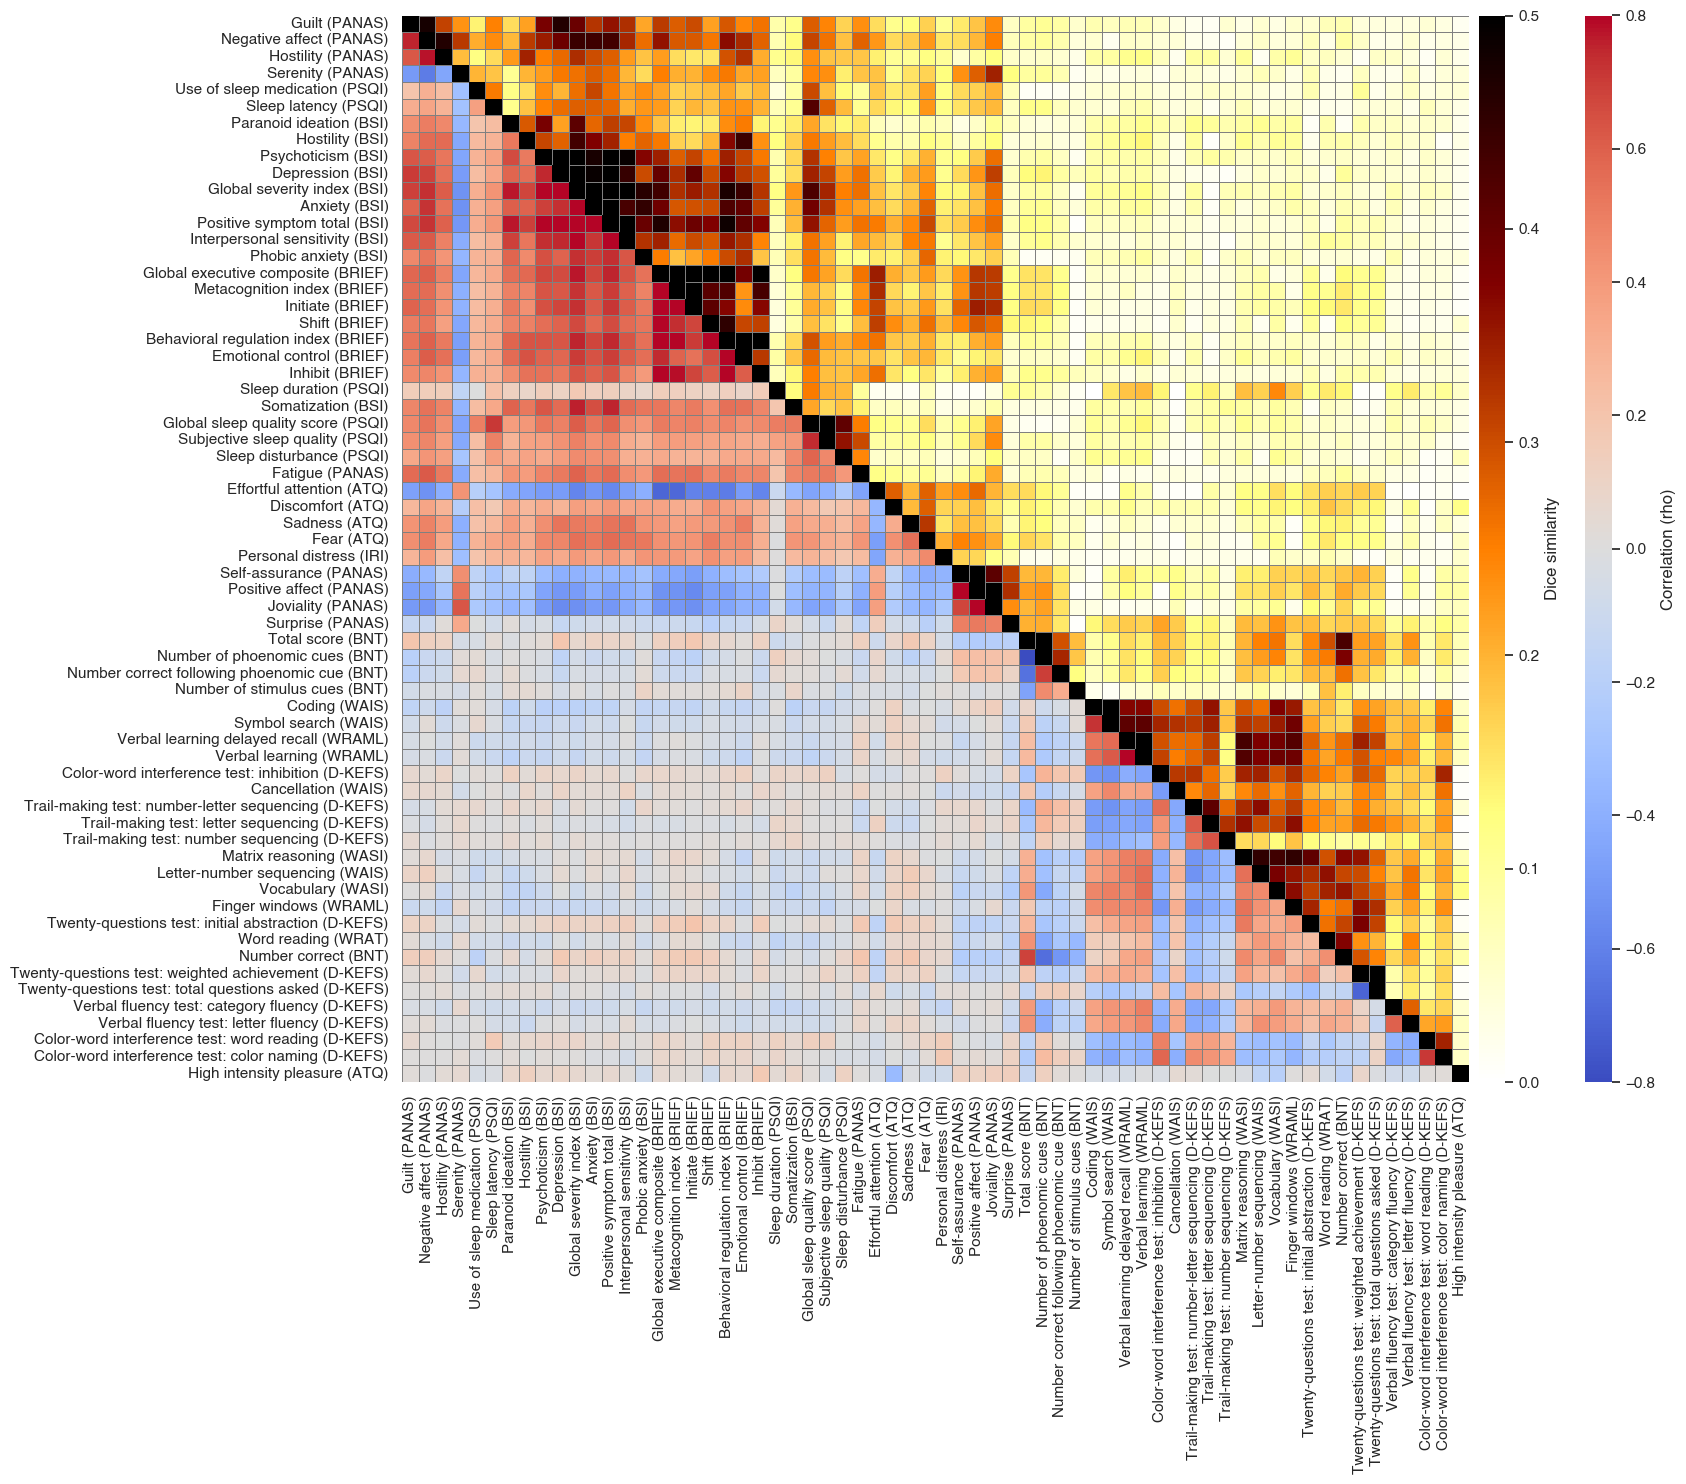

In [47]:
# Sort correlation and dice matrices based on clustering results
corrmat_combined = df_data_combined.corr(method='spearman')
sorted_corrmat_combined = corrmat_combined.loc[sorted_lbls, sorted_lbls]

# Assume square DataFrames with identical labels
labels = sorted_corrmat_combined.index
n = len(labels)

# Build combined matrix with NaNs
combined = np.full((n, n), np.nan)

# Fill upper and lower triangles
iu = np.triu_indices(n, k=1)
il = np.tril_indices(n, k=-1)
combined[iu] = sorted_dice_df.values[iu]
combined[il] = sorted_corrmat_combined.values[il]

# Diagonal gets sentinel value
np.fill_diagonal(combined, -999)

# Masks
mask_upper = np.tril(np.ones_like(combined, dtype=bool), k=-1)
mask_lower = np.triu(np.ones_like(combined, dtype=bool), k=1)

# Plot setup
fig, ax = plt.subplots(figsize=(20, 15))
divider = make_axes_locatable(ax)

# Create two stacked colorbars on the right
cax_corr = divider.append_axes("right", size="2.5%", pad=0.1)
cax_dice = divider.append_axes("right", size="2.5%", pad=0.8)  # pad > cax_corr

# Plot upper triangle (Dice)
sns.heatmap(combined, mask=mask_lower, cmap='coolwarm', ax=ax,
            square=True, cbar=True, vmin=-0.8, vmax=0.8, linewidths=0.5,
            linecolor='gray', cbar_ax=cax_dice)
cax_dice.set_ylabel("Correlation (rho)")
cax_dice.yaxis.set_label_position("right")
cax_dice.yaxis.set_ticks_position("right")

# Plot lower triangle (Correlation)
sns.heatmap(combined, mask=mask_upper, cmap='afmhot_r', ax=ax,
            square=True, cbar=True, vmin=0, vmax=0.5, linewidths=0.5,
            linecolor='gray', cbar_ax=cax_corr)
cax_corr.set_ylabel("Dice similarity")
cax_corr.yaxis.set_label_position("right")
cax_corr.yaxis.set_ticks_position("right")

# Draw black diagonal blocks
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, color='black', lw=0))

# Tick labels
ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()

In [73]:
from scipy.stats import ttest_ind

M = np.asarray(sorted_dice_df)

A = M[0:37, 0:37]
B = M[37:64, 0:37]
C = M[37:64, 37:64]

A_vals = A[np.tril_indices(37, k=-1)]
B_vals = B.ravel()
C_vals = C[np.tril_indices(27, k=-1)]

A_vals = A_vals[np.isfinite(A_vals)]
B_vals = B_vals[np.isfinite(B_vals)]
C_vals = C_vals[np.isfinite(C_vals)]

def welch_ttest(x, y):
    n1, n2 = len(x), len(y)
    mean1, mean2 = np.mean(x), np.mean(y)
    var1, var2 = np.var(x, ddof=1), np.var(y, ddof=1)
    t = (mean1 - mean2) / np.sqrt(var1/n1 + var2/n2)
    df = (var1/n1 + var2/n2)**2 / ((var1**2)/((n1**2)*(n1-1)) + (var2**2)/((n2**2)*(n2-1)))
    return t, df

# 1) A vs B
t1, df1 = welch_ttest(A_vals, B_vals)
_, p1 = ttest_ind(A_vals, B_vals, equal_var=False)

# 2) C vs B
t2, df2 = welch_ttest(C_vals, B_vals)
_, p2 = ttest_ind(C_vals, B_vals, equal_var=False)

print(f"Test 1: t={t1:.4f}, df={df1:.2f}, p={p1:.4e}, nA={A_vals.size}, nB={B_vals.size}")
print(f"Test 2: t={t2:.4f}, df={df2:.2f}, p={p2:.4e}, nC={C_vals.size}, nB={B_vals.size}")

Test 1: t=31.6780, df=788.66, p=1.0140e-142, nA=666, nB=999
Test 2: t=23.3901, df=389.11, p=3.4581e-76, nC=351, nB=999


# Figure 5

In [52]:
# Load shen atlas and gradients information for plotting 
shen_atlas_path = "/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/shen_2mm_268_parcellation_vol.nii"
shen_atlas = nib.load(shen_atlas_path)
shen_data = shen_atlas.get_fdata()

def make_brainplots(nodedata, vmin, vmax, color,
                    left_surface_path, right_surface_path):
    """
    Plot surface data on custom cortex + cerebellum surfaces with sulcal shading.

    Parameters:
    - nodedata: 268-element array of values to project
    - vmin, vmax: colormap bounds
    - color: string name of colormap
    - left_surface_path/right_surface_path: .surf.gii paths with cortex + cerebellum
    - sulc_left_path/sulc_right_path: .gii paths to sulcal maps
    - shen_data: 3D numpy array of Shen atlas labels
    - shen_affine: affine matrix from the atlas
    """
    # Create custom colormap
    cmap = plt.get_cmap(color)
    colors = [(0, 0, 0)] + [cmap(i) for i in np.linspace(0, 1, 255)]
    custom_cmap = LinearSegmentedColormap.from_list('custom_map', colors)

    # Create 3D volume of degree values
    degree_map = np.zeros_like(shen_data)
    for i in range(268):
        degree_map[shen_data == (i + 1)] = nodedata[i]
    degree_img = nib.Nifti1Image(degree_map, affine=shen_atlas.affine)
    
    def _vertex_normals(coords, faces):
        # area-weighted per-face normals
        v0 = coords[faces[:, 0]]
        v1 = coords[faces[:, 1]]
        v2 = coords[faces[:, 2]]
        n = np.cross(v1 - v0, v2 - v0)  # face normals (not unit yet)
        # accumulate to vertices
        vn = np.zeros_like(coords, dtype=np.float64)
        for k in range(3):
            np.add.at(vn, faces[:, k], n)
        # normalize
        norm = np.linalg.norm(vn, axis=1, keepdims=True)
        norm[norm == 0] = 1.0
        return (vn / norm).astype(np.float32)

    def _lambert_shade(normals, light_dir=np.array([0.3, 0.3, 0.9], dtype=np.float64)):
        # unit light
        L = light_dir / np.linalg.norm(light_dir)
        s = (normals @ L)  # [-1, 1]
        s = (s + 1.0) * 0.5  # [0, 1]
        # compress to mid-gray range for nilearn bg_map
        return (0.35 + 0.45 * s).astype(np.float32)  # ~[0.35, 0.8]

    def _normalize_to_gray(sulc):
        # normalize fs sulc to a similar mid-gray band so cortex + subcortex match
        s = (sulc - np.nanmin(sulc)) / (np.nanmax(sulc) - np.nanmin(sulc) + 1e-12)
        return (0.35 + 0.45 * (1.0 - s)).astype(np.float32)  # invert so sulci appear darker

    def build_bg_map(coords, faces, hemi):
        """Cortex uses fs sulc; cereb+brainstem use normal-based shading."""
        fsavg = datasets.fetch_surf_fsaverage(mesh='fsaverage')
        fs_coords_ref, _ = surface.load_surf_mesh(fsavg.pial_left if hemi == 'left' else fsavg.pial_right)
        n_fs = fs_coords_ref.shape[0]  # cortex is first block in your combined files

        # fs sulc for cortex block
        fs_sulc = surface.load_surf_data(fsavg.sulc_left if hemi == 'left' else fsavg.sulc_right)
        bg_cortex = _normalize_to_gray(fs_sulc)

        # normals-based shading for the whole mesh, then take only cereb+brainstem part
        vn_all = _vertex_normals(coords, faces)
        shade_all = _lambert_shade(vn_all)
        bg_cereb_bs = shade_all[n_fs:]  # everything after cortex

        # concatenate
        return np.concatenate([bg_cortex, bg_cereb_bs])

    # Load surfaces
    surf_left_coords, surf_left_faces = surface.load_surf_mesh(left_surface_path)
    surf_right_coords, surf_right_faces = surface.load_surf_mesh(right_surface_path)

    # # Load the sulcal curvature map to enhance sulci visibility
    surf_left_coords,  surf_left_faces  = surface.load_surf_mesh(left_surface_path)
    surf_right_coords, surf_right_faces = surface.load_surf_mesh(right_surface_path)

    # Build background maps with texture for cereb+brainstem
    sulc_left  = build_bg_map(surf_left_coords,  surf_left_faces,  hemi='left')
    sulc_right = build_bg_map(surf_right_coords, surf_right_faces, hemi='right')
    
    # Project volume to surface
    surf_data_left = surface.vol_to_surf(degree_img, (surf_left_coords, surf_left_faces))
    surf_data_right = surface.vol_to_surf(degree_img, (surf_right_coords, surf_right_faces))

    # Set up plot
    fig = plt.figure(figsize=(7, 7), facecolor="white")
    ax0 = fig.add_axes([0.1, 0.56, 0.45, 0.45], projection='3d', facecolor="white")  # top-left
    ax1 = fig.add_axes([0.52, 0.56, 0.45, 0.45], projection='3d', facecolor="white")  # top-right
    ax2 = fig.add_axes([0.1, 0.2, 0.45, 0.46], projection='3d', facecolor="white")  # bottom-left
    ax3 = fig.add_axes([0.52, 0.2, 0.45, 0.46], projection='3d', facecolor="white")  # bottom-right

    # Plot all 4 views with shading
    plotting.plot_surf_stat_map(
        (surf_left_coords, surf_left_faces), surf_data_left, hemi='left', view='lateral',
        cmap=custom_cmap, threshold=vmin, vmin=vmin, vmax=vmax, 
        bg_map=sulc_left, bg_on_data=True, darkness=0.5, alpha=0.75, axes=ax0, colorbar=False
    )
    plotting.plot_surf_stat_map(
        (surf_right_coords, surf_right_faces), surf_data_right, hemi='right', view='lateral',
        cmap=custom_cmap, threshold=vmin, vmin=vmin, vmax=vmax,
        bg_map=sulc_right, bg_on_data=True, darkness=0.5, alpha=0.75, axes=ax1, colorbar=False
    )
    plotting.plot_surf_stat_map(
        (surf_left_coords, surf_left_faces), surf_data_left, hemi='left', view='medial',
        cmap=custom_cmap, threshold=vmin, vmin=vmin, vmax=vmax, 
        bg_map=sulc_left, bg_on_data=True, darkness=0.5, alpha=0.75, axes=ax2, colorbar=False
    )
    plotting.plot_surf_stat_map(
        (surf_right_coords, surf_right_faces), surf_data_right, hemi='right', view='medial',
        cmap=custom_cmap, threshold=vmin, vmin=vmin, vmax=vmax, 
        bg_map=sulc_right, bg_on_data=True, darkness=0.5, alpha=0.75, axes=ax3, colorbar=False
    )

    # Optional colorbar
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])

    plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])
    return fig  

In [54]:
positive = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0,0,1,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,1,0,1,1,1]
positive_sorted = [positive[i] for i in sorted_ixs]

df_PosNets_combined = pd.concat([df_PosSymp_networks_sig, df_Poscog_networks_sig], axis=1)
df_NegNets_combined = pd.concat([df_NegSymp_networks_sig, df_Negcog_networks_sig], axis=1)

n_meas = df_NegNets_combined.shape[1]

# # sort network dfs
df_PosNets_combined_sorted = df_PosNets_combined.iloc[:,sorted_ixs]
df_NegNets_combined_sorted = df_NegNets_combined.iloc[:,sorted_ixs]

# Set min/max color range for plotting
vmin = -1.5
vmax = 1.5

# Path to the surface files
left_surface = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/left_surface.gii'
right_surface = '/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/right_surface.gii'

# Manually type in indexes of measures in each cluster and indicate which to flip the positive/negative networks to make them consistent within each cluster 
clus_ix = [[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[15,16,17,18,19,20,21],[22,23,24,25,26,27],[28,29,30,31,32],[33,34,35,36],[37,38,39,40],[41,42,43,44,45,46,47,48,49],[50,51,52,53,54,55,56,57,58],[59,60,61,62,63]]  
flip = [[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0],[0,0,0,0,0,0],[1,0,0,0,0],[0,0,0,0],[0,1,0,1],[0,0,0,0,1,0,1,1,1],[0,0,0,0,0,0,0,0,1],[0,0,1,1,1]]
        
numclust = len(clus_ix)

posmat_sums_z = np.zeros((268,268,numclust))
negmat_sums_z = np.zeros((268,268,numclust))

for cl in range(numclust):

    nummeas = len(clus_ix[cl])

    # Convert each to a matrix
    posmat = np.zeros((268,268,nummeas))
    negmat = np.zeros((268,268,nummeas))

    for m in range(nummeas):

        ix = -1

        posvec = df_PosNets_combined_sorted.iloc[:,clus_ix[cl][m]].to_numpy()
        negvec = df_NegNets_combined_sorted.iloc[:,clus_ix[cl][m]].to_numpy()

        for r in range(268):
            for c in range(268):
                if r < c:
                    ix=ix+1

                    # if positive_sorted[clus_ix[m]] == 1:
                    if flip[cl][m] == 0:
                        posmat[r,c,m] = posvec[ix]
                        negmat[r,c,m] = negvec[ix]

                    # flip positive to negative in case higher numbers are good for this scale
                    else:  
                        posmat[r,c,m] = negvec[ix]
                        negmat[r,c,m] = posvec[ix]
                elif r == c:
                    posmat[r,c,m] = 0
                    negmat[r,c,m] = 0

        posmat[:,:,m] = posmat[:,:,m] + posmat[:,:,m].T
        negmat[:,:,m] = negmat[:,:,m] + negmat[:,:,m].T


    # Sum across all edges in all matrices
    posmat_sums = np.sum(posmat, axis=2)
    negmat_sums = np.sum(negmat, axis=2)

    # z-score matricex
    posmat_sums_z[:,:,cl] = stats.zscore(posmat_sums)
    negmat_sums_z[:,:,cl] = stats.zscore(negmat_sums)

    # Sum across rows
    posmat_degree = np.sum(posmat_sums, axis=1)
    negmat_degree = np.sum(negmat_sums, axis=1)

    # z-score
    posmat_degree = stats.zscore(posmat_degree)
    negmat_degree = stats.zscore(negmat_degree)
    
    if cl <= 4: 
        color = 'plasma'  
    else:
        color = 'plasma'
    
    # === save positive ===
    fig_pos = make_brainplots(posmat_degree, vmin, vmax, color, left_surface, right_surface)
    fig_pos.savefig(f"cluster_{cl}_positive.jpg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig_pos)

    # === save negative ===
    fig_neg = make_brainplots(negmat_degree, vmin, vmax, color, left_surface, right_surface)
    fig_neg.savefig(f"cluster_{cl}_negative.jpg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig_neg)

/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_86875/4253734240.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])
/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_86875/4253734240.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])
/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_86875/4253734240.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])
/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_86875/4253734240.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])
/var/folders/fr/

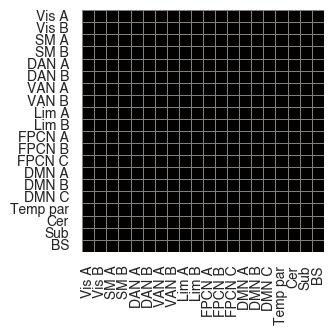

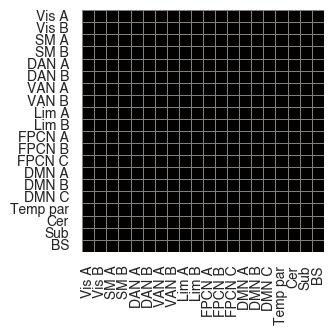

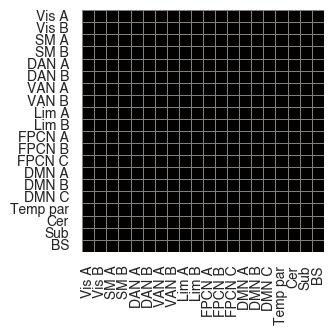

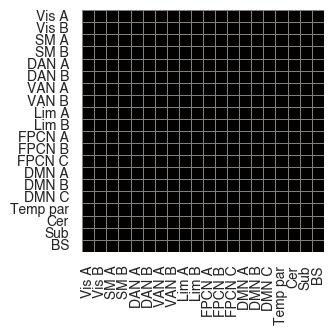

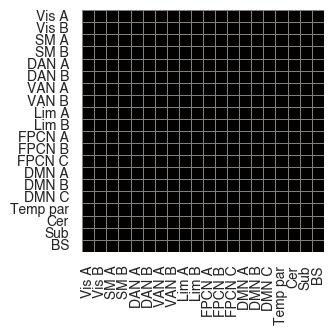

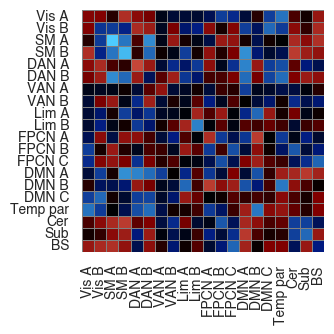

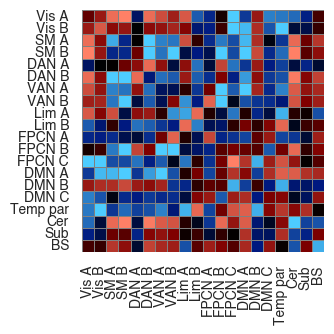

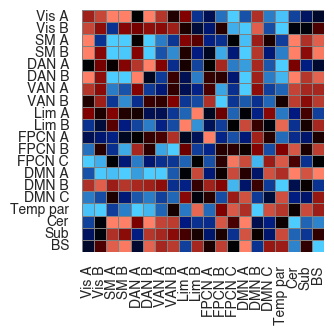

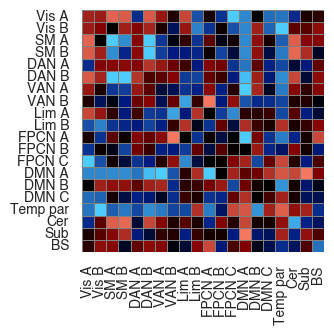

In [55]:
## Generate heatmaps to show edge distribution -- also repeat this for each cluster separately

labels_df = pd.read_csv("/Users/ajsimon/Dropbox/Manuscripts/TDS_allPredictions/Code/Parc268toYeo17netlabel_CBL_SUB_BS.txt", header=None, sep="\t")

# Define network names
network_names = ['Vis A', 'Vis B', 'SM A', 'SM B', 'DAN A', 'DAN B', 'VAN A', 'VAN B', 'Lim A', 'Lim B', 'FPCN A', 'FPCN B', 'FPCN C', 'DMN A', 'DMN B', 'DMN C', 'Temp par', 'Cer', 'Sub', 'BS']

# Assign each node to a network
network_assignments = labels_df.values.argmax(axis=1)

# Get sort indices based on network assignments
sorted_net_ixs = np.argsort(network_assignments)
sorted_network_assignments = network_assignments[sorted_net_ixs]

for cl in range(numclust):
# Apply sorting to both rows and columns
    mat_sums = posmat_sums_z[:,:,cl] - negmat_sums_z[:,:,cl]

    sums_sorted = mat_sums[np.ix_(sorted_net_ixs, sorted_net_ixs)]

    # Find where each network block ends
    boundaries = []
    current_net = sorted_network_assignments[0]
    for i in range(1, len(sorted_network_assignments)):
        if sorted_network_assignments[i] != current_net:
            boundaries.append(i)
            current_net = sorted_network_assignments[i]

    # Compute tick positions for network labels
    tick_positions = []
    last_ix = 0
    for net in range(len(network_names)):
        count = np.sum(sorted_network_assignments == net)
        tick_positions.append(last_ix + count // 2)
        last_ix += count

    # Plot
    colors = [
        (0.3, 0.8, 1.0),  # Bright saturated blue
        (0.0, 0.1, 0.5),  # Deep saturated blue
        (0.0, 0.0, 0.0),  # Black center
        (0.5, 0.0, 0.0),  # Deep saturated red
        (1.0, 0.5, 0.4)   # Bright saturated red
    ]

    # Position the fade to black in the middle but make it narrow (closer together)
    positions = [0.0, 0.4, 0.5, 0.6, 1.0]  # Controls where each color lands

    # Build the colormap
    custom_cmap = LinearSegmentedColormap.from_list("subtle_blue_black_red", list(zip(positions, colors)), N=256)

    netlabels = {}
    for n in range(268):
        netlabels[n] = network_names[network_assignments[n]]

    # Number of networks
    n_networks = len(network_names)

    # Initialize reduced matrix
    reduced_mat = np.zeros((n_networks, n_networks))

    # Loop through each pair of networks
    for i in range(n_networks):
        for j in range(n_networks):
            # Get indices for nodes in network i and network j
            idx_i = np.where(network_assignments == i)[0]
            idx_j = np.where(network_assignments == j)[0]

            # # Extract submatrix and compute mean
            block_mean = np.mean(mat_sums[np.ix_(idx_i, idx_j)])
            reduced_mat[i, j] = reduced_mat[j, i] = block_mean

    fig = plt.figure(figsize=(4.5, 3.5))
    ax = sns.heatmap(
        reduced_mat,
        vmin=-1, vmax=1,
        cmap=custom_cmap,
        xticklabels=network_names,
        yticklabels=network_names,
        square=True,
        cbar=False,
        linewidths=0.5,
        linecolor='gray'
    )
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    # Save figure
    fig.savefig(f"cluster_{cl}_matrix.jpg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)

# Figure 6

In [48]:
sorted_pval_df = pval_df.loc[sorted_lbls, sorted_lbls]

pvals_flat_sorted = sorted_pval_df.values.flatten()
_, pvals_corrected_sorted, _, _ = multipletests(pvals_flat_sorted, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pvals_corrected_sorted.reshape(sorted_pval_df.shape)
pval_corrected_df_sorted = pd.DataFrame(pval_corrected_matrix, index=sorted_pval_df.columns, columns=sorted_pval_df.columns)

# Mask p-values greater than 0.05 and set them to black
masked_pval_sorted = pval_corrected_df_sorted.copy()
masked_pval_sorted[pval_corrected_df_sorted > 0.05] = np.nan

pval_corrected_sympcog_df_sorted = masked_pval_sorted.iloc[37:63, list(range(0, 37)) + [63]]

sympcog_corrmat_df = sorted_corrmat_combined.iloc[37:63, list(range(0, 37)) + [63]]

sympcog_corrmat_masked_df = sympcog_corrmat_df.copy()
sympcog_corrmat_masked_df[pval_corrected_sympcog_df_sorted.isna()] = np.nan 

# Trim 'corrmat_combined', 'pval_df', and 'dice_df' so that they only contain rows 39:64 and columns 0:37
sympcog_data_df = sorted_corrmat_combined.iloc[37:63, list(range(0, 37)) + [63]]
sympcog_pval_df = masked_pval_sorted.iloc[37:63, list(range(0, 37)) + [63]]

# sympcog_pval_df = pval_corrected_sympcog_df_sorted
sympcog_pval_df[sympcog_pval_df > 0.05] = np.nan

# # Sort these
netscore_sorted = netscore[np.ix_(sorted_ixs, sorted_ixs, range(netscore.shape[2]))]
sympcog_netscore_sorted = netscore_sorted[37:63, list(range(0, 37)) + [63],:]

degree_z_sorted = degree_sympcog_z[np.ix_(sorted_ixs, sorted_ixs, range(degree_sympcog_z.shape[2]))]
degree_sympcog_z_sorted = degree_z_sorted[37:63, list(range(0, 37)) + [63],:]

# Vectorize the overlapping networks matrix
masked_pval_array = sympcog_pval_df.to_numpy() if isinstance(sympcog_pval_df, pd.DataFrame) else sympcog_pval_df

# # Find the (row, col) indices where masked_pval_filtered is NOT NaN
valid_indices = np.argwhere(~np.isnan(masked_pval_array))  # Shape (101,2)

valid_rows = ~np.all(np.isnan(masked_pval_array), axis=1)
valid_cols = ~np.all(np.isnan(masked_pval_array), axis=0)

netscore_filtered = sympcog_netscore_sorted[np.ix_(valid_rows, valid_cols, np.arange(sympcog_netscore_sorted.shape[2]))]

# Extract corresponding vectors from filtered_degree_sympcog_z
degree_vectors = np.array([
    degree_sympcog_z_sorted[row, col, :] for row, col in valid_indices
]).T  # Transpose to get shape (268,30)

overlapping_edges_2d = np.array([
    overlap_matrix[row,col,:] for row, col in valid_indices
]).T

# Generate column names using row and column indices
column_names = [
    f"{sympcog_pval_df.index[row]} X {sympcog_pval_df.columns[col]}"
    for row, col in valid_indices
]

# convert vectors of overlapping edges and nodes to dataframes
overlapping_edges_2d_df = pd.DataFrame(overlapping_edges_2d, columns=column_names)
overlapping_nodes_df = pd.DataFrame(degree_vectors, columns=column_names)

In [50]:
# Run the mediation with symp as the independent variable and cog as the dependent
mediation_results_symp_to_cog = pd.DataFrame(index=sympcog_corrmat_masked_df.index, columns=sympcog_corrmat_masked_df.columns)

# Iterate over cognitive variables (cog_var) and symptom variables (symp_var)
for c, var1 in enumerate(mediation_results_symp_to_cog.index):
    for s, var2 in enumerate(mediation_results_symp_to_cog.columns):

        if np.isnan(sympcog_corrmat_masked_df.iloc[c,s]):
            mediation_results_symp_to_cog.loc[var1, var2] = np.nan
        else:
            # Extract values
            X = df_data_combined[var2].values  # Predictor
            Y = df_data_combined[var1].values  # Outcome
            M = sympcog_netscore_sorted[c, s, :]  # Mediator (specific to current (cog_var, symp_var))
            
            scaler = StandardScaler()
            X_z = scaler.fit_transform(X.reshape(-1, 1)).flatten()
            Y_z = scaler.fit_transform(Y.reshape(-1, 1)).flatten()
            M_z = scaler.fit_transform(M.reshape(-1, 1)).flatten()

            # Stack data into a DataFrame for NaN removal
            df = pd.DataFrame({"X": X_z, "Y": Y_z, "M": M_z}).dropna()

            # Drop rows with any NaN values in the relevant columns
            tempdata = df[['X', 'M', 'Y']].dropna()

            # Perform mediation analysis
            this_med_results = pg.mediation_analysis(data=tempdata, 
                                             x='X', 
                                             m='M', 
                                             y='Y', 
                                             alpha=0.01, 
                                             n_boot=1000)  # Number of bootstraps for CI

            indirect_sig = this_med_results["sig"][4]  # Extract p-value
            indirect_effect = this_med_results["coef"][4]  # Extract indirect effect coefficient

            mediation_results_symp_to_cog.loc[var1, var2] = indirect_effect if indirect_sig == 'Yes' else np.nan
            
# Run the mediation with symp as the independent variable and cog as the dependent
mediation_results_cog_to_symp = pd.DataFrame(index=sympcog_corrmat_masked_df.index, columns=sympcog_corrmat_masked_df.columns)

# Iterate over cognitive variables (cog_var) and symptom variables (symp_var)
for c, var1 in enumerate(mediation_results_cog_to_symp.index):
    for s, var2 in enumerate(mediation_results_cog_to_symp.columns):

        if np.isnan(sympcog_corrmat_masked_df.iloc[c,s]):
            mediation_results_cog_to_symp.loc[var1, var2] = np.nan
        else:
            # Extract values
            Y = df_data_combined[var2].values  # Predictor
            X = df_data_combined[var1].values  # Outcome
            M = sympcog_netscore_sorted[c, s, :]  # Mediator (specific to current (cog_var, symp_var))
            
            scaler = StandardScaler()
            X_z = scaler.fit_transform(X.reshape(-1, 1)).flatten()
            Y_z = scaler.fit_transform(Y.reshape(-1, 1)).flatten()
            M_z = scaler.fit_transform(M.reshape(-1, 1)).flatten()

            # Stack data into a DataFrame for NaN removal
            df = pd.DataFrame({"X": X_z, "Y": Y_z, "M": M_z}).dropna()

            # Drop rows with any NaN values in the relevant columns
            tempdata = df[['X', 'M', 'Y']].dropna()

            # Perform mediation analysis
            this_med_results = pg.mediation_analysis(data=tempdata, 
                                             x='X', 
                                             m='M', 
                                             y='Y', 
                                             alpha=0.01, 
                                             n_boot=1000)  # Number of bootstraps for CI

            indirect_sig = this_med_results["sig"][4]  # Extract p-value
            indirect_effect = this_med_results["coef"][4]  # Extract indirect effect coefficient

            mediation_results_cog_to_symp.loc[var1, var2] = indirect_effect if indirect_sig == 'Yes' else np.nan

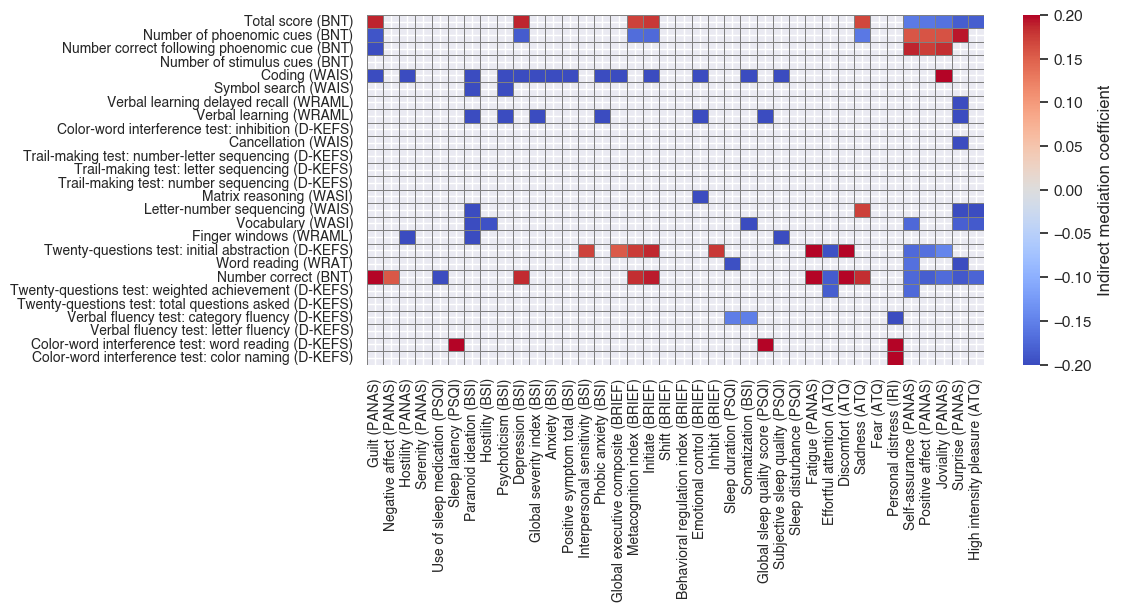

In [51]:
# Take absolute values
abs_c2s = mediation_results_cog_to_symp.abs()
abs_s2c = mediation_results_symp_to_cog.abs()

# Use np.maximum to get the greater absolute value
max_abs_vals = np.maximum(abs_c2s, abs_s2c)

# Retain the sign from the original dataframe that had the greater abs value
combined_mediation = mediation_results_cog_to_symp.copy()

# Use a mask where symp_to_cog had the greater abs value
mask = abs_s2c > abs_c2s

# Replace those values in combined_mediation with the symp_to_cog values
combined_mediation[mask] = mediation_results_symp_to_cog[mask]

plt.figure(figsize=(12, 6.5))

ax = sns.heatmap(combined_mediation.astype(float), annot=False, cmap="coolwarm", fmt=".2f", cbar=True, vmin=-.2, vmax=.2, center=0, linewidths=.5, linecolor='gray',cbar_kws={'label': 'Indirect mediation coefficient'})

plt.xticks(rotation=90, ha='right',va='center', rotation_mode='anchor')
plt.yticks(rotation=0)
plt.tight_layout()
ax.tick_params(axis='both', which='major', labelsize=10)  # Adjust the fontsize of major ticks
plt.show()

In [100]:
## Plot the degree of mediating nodes
# List the column names you want to extract from overlapping_edges_2d_df

# var_names = ['Verbal fluency test: category fluency (D-KEFS) X Sleep duration (PSQI)','Verbal fluency test: category fluency (D-KEFS) X Somatization (BSI)','Color-word interference test: word reading (D-KEFS) X Global sleep quality score (PSQI)']
# var_names = ['Color-word interference test: word reading (D-KEFS) X Sleep latency (PSQI)']
# var_names = ['Color-word interference test: word reading (D-KEFS) X Sleep latency (PSQI)']
# var_names = ['Twenty-questions test: weighted achievement (D-KEFS) X Self-assurance (PANAS)','Number correct (BNT) X Self-assurance (PANAS)','Number correct (BNT) X Positive affect (PANAS)','Number correct (BNT) X Joviality (PANAS)','Number correct (BNT) X Surprise (PANAS)','Word reading (WRAT) X Self-assurance (PANAS)','Word reading (WRAT) X Surprise (PANAS)','Twenty-questions test: initial abstraction (D-KEFS) X Self-assurance (PANAS)','Twenty-questions test: initial abstraction (D-KEFS) X Positive affect (PANAS)','Twenty-questions test: initial abstraction (D-KEFS) X Joviality (PANAS)','Vocabulary (WASI) X Self-assurance (PANAS)','Vocabulary (WASI) X Surprise (PANAS)','Letter-number sequencing (WAIS) X Surprise (PANAS)']
# var_names = ['Letter-number sequencing (WAIS) X Sadness (ATQ)','Twenty-questions test: initial abstraction (D-KEFS) X Effortful attention (ATQ)','Twenty-questions test: initial abstraction (D-KEFS) X Discomfort (ATQ)','Number correct (BNT) X Effortful attention (ATQ)','Number correct (BNT) X Discomfort (ATQ)','Number correct (BNT) X Sadness (ATQ)','Twenty-questions test: weighted achievement (D-KEFS) X Effortful attention (ATQ)']
# var_names = ['Number correct (BNT) X Metacognition index (BRIEF)','Number correct (BNT) X Initiate (BRIEF)','Twenty-questions test: initial abstraction (D-KEFS) X Inhibit (BRIEF)','Twenty-questions test: initial abstraction (D-KEFS) X Initiate (BRIEF)','Twenty-questions test: initial abstraction (D-KEFS) X Metacognition index (BRIEF)','Twenty-questions test: initial abstraction (D-KEFS) X Global executive composite (BRIEF)','Matrix reasoning (WASI) X Emotional control (BRIEF)']
# var_names = ['Word reading (WRAT) X Sleep duration (PSQI)','Vocabulary (WASI) X Somatization (BSI)','Finger windows (WRAML) X Subjective sleep quality (PSQI)','Twenty-questions test: initial abstraction (D-KEFS) X Fatigue (PANAS)','Number correct (BNT) X Fatigue (PANAS)']
# var_names = ['Number correct (BNT) X Guilt (PANAS)','Number correct (BNT) X Negative affect (PANAS)','Number correct (BNT) X Use of sleep medication (PSQI)','Number correct (BNT) X Depression (BSI)','Finger windows (WRAML) X Hostility (PANAS)','Finger windows (WRAML) X Paranoid ideation (BSI)','Twenty-questions test: initial abstraction (D-KEFS) X Interpersonal sensitivity (BSI)','Vocabulary (WASI) X Paranoid ideation (BSI)','Vocabulary (WASI) X Hostility (BSI)','Letter-number sequencing (WAIS) X Paranoid ideation (BSI)']
# var_names = ['Coding (WAIS) X Joviality (PANAS)','Verbal learning delayed recall (WRAML) X Surprise (PANAS)','Verbal learning (WRAML) X Surprise (PANAS)','Cancellation (WAIS) X Surprise (PANAS)']
# var_names = ['Coding (WAIS) X Somatization (BSI)','Coding (WAIS) X Subjective sleep quality (PSQI)','Verbal learning (WRAML) X Global sleep quality score (PSQI)']
# var_names = ['Coding (WAIS) X Global executive composite (BRIEF)','Coding (WAIS) X Initiate (BRIEF)','Coding (WAIS) X Emotional control (BRIEF)','Verbal learning (WRAML) X Emotional control (BRIEF)']
# var_names = ['Coding (WAIS) X Guilt (PANAS)','Coding (WAIS) X Hostility (PANAS)','Coding (WAIS) X Paranoid ideation (BSI)','Coding (WAIS) X Psychoticism (BSI)','Coding (WAIS) X Depression (BSI)','Coding (WAIS) X Global severity index (BSI)','Coding (WAIS) X Anxiety (BSI)','Coding (WAIS) X Positive symptom total (BSI)','Coding (WAIS) X Phobic anxiety (BSI)','Symbol search (WAIS) X Paranoid ideation (BSI)','Symbol search (WAIS) X Psychoticism (BSI)','Verbal learning (WRAML) X Paranoid ideation (BSI)','Verbal learning (WRAML) X Psychoticism (BSI)','Verbal learning (WRAML) X Global severity index (BSI)','Verbal learning (WRAML) X Phobic anxiety (BSI)']
# var_names = ['Total score (BNT) X Self-assurance (PANAS)','Total score (BNT) X Positive affect (PANAS)','Total score (BNT) X Joviality (PANAS)','Total score (BNT) X Surprise (PANAS)','Number of phoenomic cues (BNT) X Self-assurance (PANAS)','Number of phoenomic cues (BNT) X Positive affect (PANAS)','Number of phoenomic cues (BNT) X Joviality (PANAS)','Number of phoenomic cues (BNT) X Surprise (PANAS)','Number correct following phoenomic cue (BNT) X Self-assurance (PANAS)','Number correct following phoenomic cue (BNT) X Positive affect (PANAS)','Number correct following phoenomic cue (BNT) X Joviality (PANAS)']
# var_names = ['Total score (BNT) X Sadness (ATQ)','Number of phoenomic cues (BNT) X Sadness (ATQ)']
# var_names = ['Total score (BNT) X Metacognition index (BRIEF)','Total score (BNT) X Initiate (BRIEF)','Number of phoenomic cues (BNT) X Metacognition index (BRIEF)','Number of phoenomic cues (BNT) X Initiate (BRIEF)']
var_names = ['Total score (BNT) X Guilt (PANAS)','Number of phoenomic cues (BNT) X Guilt (PANAS)','Number correct following phoenomic cue (BNT) X Guilt (PANAS)','Total score (BNT) X Depression (BSI)','Number of phoenomic cues (BNT) X Depression (BSI)']

# Initialize an empty list to hold column arrays
overlapping_data = []

# Loop through each column name and append its values
for col in var_names:
    overlapping_data.append(overlapping_edges_2d_df[col].values)

overlapping_data_cluster = np.column_stack(overlapping_data)

nvars = overlapping_data_cluster.shape[1]

mat_comb = np.zeros((268,268,nvars))

for v in range(nvars):
    ix = -1
    for r in range(268):
        for c in range(268):
            if r < c:
                ix=ix+1
                mat_comb[r,c,v] = overlapping_data_cluster[ix,v]
            elif r == c:
                mat_comb[r,c,v] = 0
                
mat_comb = np.sum(mat_comb,axis=2)
mat_comb = mat_comb + mat_comb.T

mat_comb_degree = np.sum(mat_comb, axis=1)
mat_comb_degree_z = stats.zscore(mat_comb_degree)

/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_86875/4253734240.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])


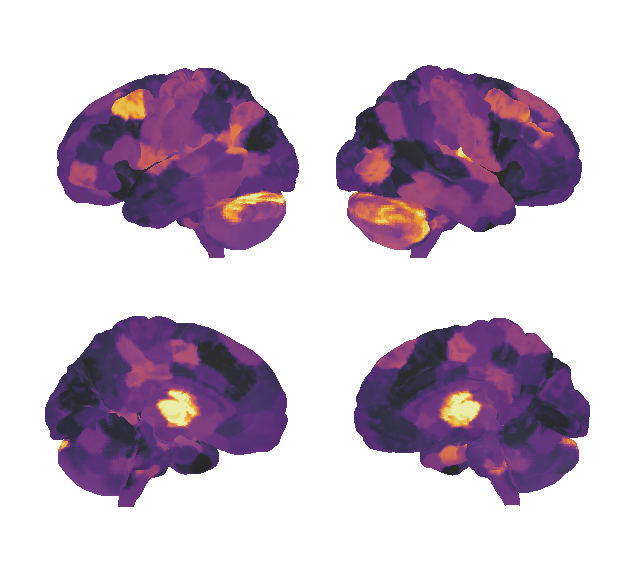

In [101]:
vmin = -1
vmax = 3

nodedata = mat_comb_degree_z

# # Replace zeros or any other mask criteria with NaN
# nodedata_clean = np.copy(nodedata)
# nodedata_clean[(nodedata == -2) | np.isnan(nodedata)] = np.nan
# nodedata_clean[(nodedata == 0) | np.isnan(nodedata)] = np.nan

color = 'inferno'  #'plasma' 

fig = make_brainplots_with_cerebellum(nodedata,vmin,vmax,color, left_surface, right_surface)
plt.show(fig)

# Figure 7

In [176]:
def make_brainplots_masked(
        nodedata, vmin, vmax, color,
        left_surface_path, right_surface_path,
        save_path, erode_rings):
    """
    Plot cortex + cerebellum with crisp parcel-locked colors (no interpolation).
    Uses nearest-voxel label lookup (no line sampling), so cerebellum parcels render reliably.
    Requires globals: shen_data (int/float labels), shen_atlas (for affine).
    """

    # ---------- colormap: NaNs transparent ----------
    base = plt.get_cmap(color)
    custom_cmap = LinearSegmentedColormap.from_list(
        'custom_map', [base(i) for i in np.linspace(0, 1, 256)]
    )
    custom_cmap.set_bad((0, 0, 0, 0))  # NaNs => transparent

    # ---------- helpers for shading / bg ----------
    def _vertex_normals(coords, faces):
        v0, v1, v2 = coords[faces[:, 0]], coords[faces[:, 1]], coords[faces[:, 2]]
        n = np.cross(v1 - v0, v2 - v0)
        vn = np.zeros_like(coords, dtype=np.float64)
        for k in range(3):
            np.add.at(vn, faces[:, k], n)
        norm = np.linalg.norm(vn, axis=1, keepdims=True)
        norm[norm == 0] = 1.0
        return (vn / norm).astype(np.float32)

    def _lambert_shade(normals, light_dir=np.array([0.3, 0.3, 0.9])):
        L = light_dir / np.linalg.norm(light_dir)
        s = (normals @ L)
        s = (s + 1.0) * 0.5
        return (0.35 + 0.45 * s).astype(np.float32)

    def _normalize_to_gray(sulc):
        s = (sulc - np.nanmin(sulc)) / (np.nanmax(sulc) - np.nanmin(sulc) + 1e-12)
        return (0.35 + 0.45 * (1.0 - s)).astype(np.float32)

    def build_bg_map(coords, faces, hemi):
        fsavg = datasets.fetch_surf_fsaverage(mesh='fsaverage')
        fs_coords_ref, _ = surface.load_surf_mesh(
            fsavg.pial_left if hemi == 'left' else fsavg.pial_right
        )
        n_fs = fs_coords_ref.shape[0]
        fs_sulc = surface.load_surf_data(
            fsavg.sulc_left if hemi == 'left' else fsavg.sulc_right
        )
        bg_cortex = _normalize_to_gray(fs_sulc)
        vn_all = _vertex_normals(coords, faces)
        shade_all = _lambert_shade(vn_all)
        bg_cereb_bs = shade_all[n_fs:]
        return np.concatenate([bg_cortex, bg_cereb_bs])

    # ---------- load meshes ----------
    Lc, Lf = surface.load_surf_mesh(left_surface_path)
    Rc, Rf = surface.load_surf_mesh(right_surface_path)

    # ---------- label lookup from nearest voxel (robust for cerebellum) ----------
    inv_aff = np.linalg.inv(shen_atlas.affine)
    shen_vol = np.asarray(shen_data, dtype=np.int32)
    nx, ny, nz = shen_vol.shape

    def labels_from_nearest_voxel(coords_mm, search=2):
        """Map each vertex to the nearest labeled voxel in a small (2-voxel) cube."""
        # world (mm) -> voxel ijk (float), then nearest integer
        ijk_float = nib.affines.apply_affine(inv_aff, coords_mm)
        ijk = np.rint(ijk_float).astype(int)

        # clip to volume
        ijk[:, 0] = np.clip(ijk[:, 0], 0, nx - 1)
        ijk[:, 1] = np.clip(ijk[:, 1], 0, ny - 1)
        ijk[:, 2] = np.clip(ijk[:, 2], 0, nz - 1)

        labels = shen_vol[ijk[:, 0], ijk[:, 1], ijk[:, 2]].astype(float)

        # fill zeros by searching a small neighborhood
        zeros = np.where(labels <= 0)[0]
        if zeros.size:
            # offsets within a (2*search+1)^3 cube
            offs = np.array([(dx, dy, dz)
                             for dx in range(-search, search + 1)
                             for dy in range(-search, search + 1)
                             for dz in range(-search, search + 1)], dtype=int)
            base = ijk[zeros][:, None, :] + offs[None, :, :]
            # clip neighbors
            base[:, :, 0] = np.clip(base[:, :, 0], 0, nx - 1)
            base[:, :, 1] = np.clip(base[:, :, 1], 0, ny - 1)
            base[:, :, 2] = np.clip(base[:, :, 2], 0, nz - 1)
            neigh = shen_vol[base[:, :, 0], base[:, :, 1], base[:, :, 2]]
            # choose first non-zero neighbor (if any)
            has_lab = neigh > 0
            any_lab = has_lab.any(axis=1)
            choice = np.argmax(has_lab, axis=1)  # index of first labeled neighbor
            fill_idx = zeros[any_lab]
            if fill_idx.size:
                pick = neigh[np.arange(neigh.shape[0])[any_lab], choice[any_lab]]
                labels[fill_idx] = pick.astype(float)
            # anything still zero -> NaN
            labels[labels <= 0] = np.nan

        return labels

    L_labels = labels_from_nearest_voxel(Lc, search=2)
    R_labels = labels_from_nearest_voxel(Rc, search=2)

    # ---------- labels -> values (parcel-locked, NaNs stay masked) ----------
    def labels_to_values(labels, values_vec):
        out = np.full(labels.shape[0], np.nan, dtype=float)
        valid = ~np.isnan(labels)
        idx = np.rint(labels[valid]).astype(int) - 1  # Shen labels start at 1
        keep = (idx >= 0) & (idx < len(values_vec))
        valid_pos = np.where(valid)[0]
        out[valid_pos[keep]] = values_vec[idx[keep]]
        return out

    L_vals = labels_to_values(L_labels, nodedata)
    R_vals = labels_to_values(R_labels, nodedata)

    # ---------- optional border erosion ----------
    if erode_rings > 0:
        def erode(values, faces, rings=1):
            adj = [[] for _ in range(values.shape[0])]
            for tri in faces:
                a, b, c = tri
                adj[a].extend([b, c]); adj[b].extend([a, c]); adj[c].extend([a, b])
            adj = [np.unique(v).astype(int) for v in adj]
            boundary = np.zeros_like(values, dtype=bool)
            for v in range(values.shape[0]):
                if not np.isnan(values[v]):
                    nv = adj[v]
                    if np.any(np.isnan(values[nv])) or np.any(values[nv] != values[v]):
                        boundary[v] = True
            mask = boundary.copy()
            for _ in range(rings - 1):
                expand = mask.copy()
                for v in np.where(mask)[0]:
                    expand[adj[v]] = True
                mask = expand
            values[mask] = np.nan
            return values
        L_vals = erode(L_vals.copy(), Lf, rings=erode_rings)
        R_vals = erode(R_vals.copy(), Rf, rings=erode_rings)

    # ---------- backgrounds ----------
    L_bg = build_bg_map(Lc, Lf, 'left')
    R_bg = build_bg_map(Rc, Rf, 'right')

    # ---------- plot ----------
    fig = plt.figure(figsize=(7, 7), facecolor="white")
    ax0 = fig.add_axes([0.1, 0.56, 0.45, 0.45], projection='3d', facecolor="white")
    ax1 = fig.add_axes([0.52, 0.56, 0.45, 0.45], projection='3d', facecolor="white")
    ax2 = fig.add_axes([0.1, 0.2, 0.45, 0.46],  projection='3d', facecolor="white")
    ax3 = fig.add_axes([0.52, 0.2, 0.45, 0.46],  projection='3d', facecolor="white")

    tiny = 1e-12  # NaNs already transparent

    plotting.plot_surf_stat_map((Lc, Lf), L_vals, hemi='left', view='lateral',
        cmap=custom_cmap, threshold=tiny, vmin=vmin, vmax=vmax,
        bg_map=L_bg, bg_on_data=True, darkness=0.5, alpha=0.95,
        axes=ax0, colorbar=False)
    plotting.plot_surf_stat_map((Rc, Rf), R_vals, hemi='right', view='lateral',
        cmap=custom_cmap, threshold=tiny, vmin=vmin, vmax=vmax,
        bg_map=R_bg, bg_on_data=True, darkness=0.5, alpha=0.95,
        axes=ax1, colorbar=False)
    plotting.plot_surf_stat_map((Lc, Lf), L_vals, hemi='left', view='medial',
        cmap=custom_cmap, threshold=tiny, vmin=vmin, vmax=vmax,
        bg_map=L_bg, bg_on_data=True, darkness=0.5, alpha=0.95,
        axes=ax2, colorbar=False)
    plotting.plot_surf_stat_map((Rc, Rf), R_vals, hemi='right', view='medial',
        cmap=custom_cmap, threshold=tiny, vmin=vmin, vmax=vmax,
        bg_map=R_bg, bg_on_data=True, darkness=0.5, alpha=0.95,
        axes=ax3, colorbar=False)

    plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    return fig

In [143]:
overlapping_edges_data = overlapping_edges_2d_df.to_numpy()

nvars = overlapping_edges_data.shape[1]

mat_comb = np.zeros((268,268,nvars))

for v in range(nvars):
    ix = -1
    for r in range(268):
        for c in range(268):
            if r < c:
                ix=ix+1
                mat_comb[r,c,v] = overlapping_edges_data[ix,v]
            elif r == c:
                mat_comb[r,c,v] = 0
                
mat_comb = np.sum(mat_comb,axis=2)
mat_comb = mat_comb + mat_comb.T

mat_comb_degree = np.sum(mat_comb, axis=1)
mat_comb_degree_z = stats.zscore(mat_comb_degree)

In [164]:
# Find the 90th percentile value
threshold = np.percentile(mat_comb_degree_z, 80)

# Keep values below threshold as NaN directly
masked_degree = np.where(mat_comb_degree_z >= threshold, mat_comb_degree_z, np.nan)

/var/folders/fr/tfcrh98d0x107gyvfnssn9wc0000gn/T/ipykernel_86875/3301868017.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, rect=[0, 0, 0.9, 1])


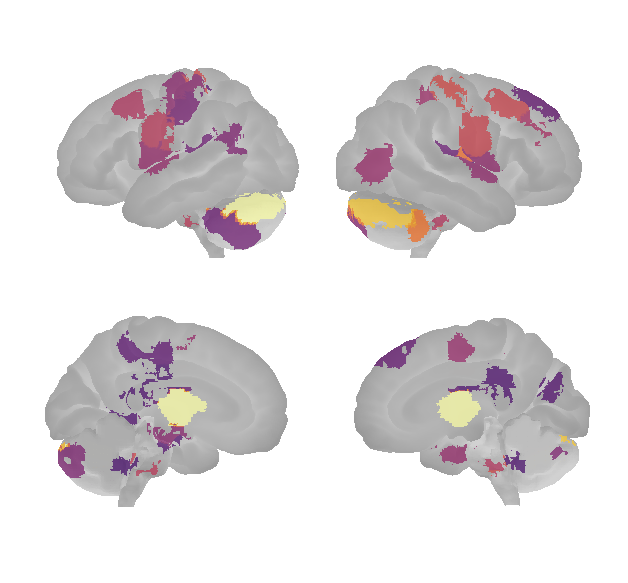

In [177]:
vmin = -0.5
vmax = 4

color = 'inferno'  #'plasma' 

nodedata_clean = masked_degree  

fig = make_brainplots_masked(nodedata_clean, vmin, vmax, color, left_surface, right_surface, save_path=None, erode_rings=0)
plt.show(fig)

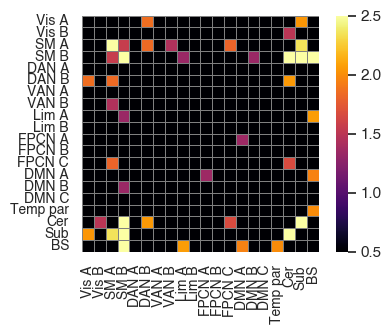

In [55]:
colors = [
    (0.3, 0.8, 1.0),  # Bright saturated blue
    (0.0, 0.1, 0.5),  # Deep saturated blue
    (0.0, 0.0, 0.0),  # Black center
    (0.5, 0.0, 0.0),  # Deep saturated red
    (1.0, 0.5, 0.4)   # Bright saturated red
]

# Position the fade to black in the middle but make it narrow (closer together)
positions = [0.0, 0.4, 0.5, 0.6, 1.0]  # Controls where each color lands

# Build the colormap
custom_cmap = LinearSegmentedColormap.from_list("subtle_blue_black_red", list(zip(positions, colors)), N=256)

# Number of networks
n_networks = len(network_names)

# Initialize reduced matrix
reduced_mat = np.zeros((n_networks, n_networks))

# Loop through each pair of networks
for i in range(n_networks):
    for j in range(n_networks):
        # Get indices for nodes in network i and network j
        idx_i = np.where(network_assignments == i)[0]
        idx_j = np.where(network_assignments == j)[0]
        
        # # Extract submatrix and compute mean
        block_mean = np.mean(mat_comb[np.ix_(idx_i, idx_j)])
        reduced_mat[i, j] = block_mean

reduced_mat_z = (reduced_mat - np.mean(reduced_mat)) / np.std(reduced_mat)

# Threshold it! Get the threshold for the top 21 (10%) unique values
flattened = reduced_mat_z.flatten()

threshold = np.sort(flattened)[-42]
mask_mat = reduced_mat_z >= threshold

thresholded_mat = np.zeros_like(reduced_mat_z)
thresholded_mat[mask_mat] = reduced_mat_z[mask_mat]


plt.figure(figsize=(4.5, 3.5))
ax = sns.heatmap(
    thresholded_mat,
    vmin=.5, vmax=2.5,
    cmap='inferno',
    xticklabels=network_names,
    yticklabels=network_names,
    square=True,
    cbar=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()